# Housing Price Prediction
## ML / Data Science / Feature Engineering

Goal: predict housing prices based on many different features

Project Overview
In this project, I performed data cleaning, exploratory data analysis (EDA), data engineering (including the creation of a reproducible pipieline for trains and test sets), feature engineering, model building, parameter tuning, and model ensembling.

Modeling Approach
I built and evaluated multiple regression models, including Linear Regression and advanced machine-learning models such as Random Forest, XGBoost, and Multilayer Perceptron (MLP).

Regularization & Tuning
To address multicollinearity and improve generalization, I implemented LASSO regularization and conducted systematic hyperparameter tuning for all models, with a particular focus on XGBoost.

Ensembling
I applied ensemble learning techniques to combine predictions from multiple models, leveraging Gradient Boosting Machines (GBM), XGBoost, Random Forest (via ranger), and Neural Networks using the caret package.

We will also create new variables ie property age and new features as well. 



Our data has a bunch of different variables .. first looked through (to see nulls)and found the important ones

In [16]:
#import relevant packages 
import pandas as pd ## for data manipulation 
import numpy as np ## dm
import plotly.graph_objects as go ## data visalization for this and go 
import plotly.express as px ## dv
import scipy.stats as stats ## for normalization 
from IPython.display import display, HTML ## for more visually readable


# Basic Data Exploration
1. Import the data
2. Look at summary statisitcs
3. Evaluate Null Values

In [17]:
#import data 
df = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")

In [18]:
# Function to create scrollable table within a small window
def create_scrollable_table(df, table_id, title):
    html = f'<h3>{title}</h3>'
    html += f'<div id="{table_id}" style="height:200px; overflow:auto;">'
    html += df.to_html()
    html += '</div>'
    return html

In [19]:
df.shape ## 81 diff features with 1460 rows

(1460, 81)

In [20]:
# Summary statistics for numerical features
## get all numerical features and transpose for longer format data
numerical_features = df.select_dtypes(include=[np.number])
summary_stats = numerical_features.describe().T
html_numerical = create_scrollable_table(summary_stats, 'numerical_features', 'Summary statistics for numerical features')

display(HTML(html_numerical))


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [21]:
# Summary statistics for categorical features
categorical_features = df.select_dtypes(include=[object]) ## chose object which is other type of data besides numerical
cat_summary_stats = categorical_features.describe().T ## .T does transpose 
html_categorical = create_scrollable_table(cat_summary_stats, 'categorical_features', 'Summary statistics for categorical features')

display(HTML(html_categorical ))


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [17]:
# Null values in the dataset
null_values = df.isnull().sum()
html_null_values = create_scrollable_table(null_values.to_frame(), 'null_values', 'Null values in the dataset')

# Percentage of missing values for each feature
missing_percentage = (df.isnull().sum() / len(df)) * 100
html_missing_percentage = create_scrollable_table(missing_percentage.to_frame(), 'missing_percentage', 'Percentage of missing values for each feature')

display(HTML(html_null_values + html_missing_percentage))

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0


In [22]:
# Exploring rows with missing values
rows_with_missing_values = df[df.isnull().any(axis=1)]
html_rows_with_missing_values = create_scrollable_table(rows_with_missing_values.head(), 'rows_with_missing_values', 'Rows with missing values')

display(HTML(html_rows_with_missing_values))


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [23]:
df.columns ## seeing what cols we have

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Explore the dependent variable and perform data Analysis (EDA)
- Should it be normalized? 
- Normalize Dependent Vairable

In [84]:
## importing this package since my graphs weren't showing
## this line is all about telling Plotly how to display figures in my specific environment on kaggle
## All Plotly figures require a renderer. On Kaggle, "iframe" is the most reliable renderer.

import plotly.io as pio
pio.renderers.default = "iframe"


## little thought to self: its good to know different packages for visualziatios but we can use chat to create visualization .. saves time and effective and easier to see visualization, we can also learn new packages this way. 


In [98]:


import scipy.stats as stats

# Fit a normal distribution to the SalePrice data
mu, sigma = stats.norm.fit(df['SalePrice'])

# Create a histogram of the SalePrice column
hist_data = go.Histogram(x=df['SalePrice'], nbinsx=50, name="Histogram", opacity=0.75, histnorm='probability density', marker=dict(color='purple'))

# Calculate the normal distribution based on the fitted parameters
x_norm = np.linspace(df['SalePrice'].min(), df['SalePrice'].max(), 100)
y_norm = stats.norm.pdf(x_norm, mu, sigma)

# Create the normal distribution overlay
norm_data = go.Scatter(x=x_norm, y=y_norm, mode="lines", name=f"Normal dist. (μ={mu:.2f}, σ={sigma:.2f})", line=dict(color="green"))

# Combine the histogram and the overlay
fig = go.Figure(data=[hist_data, norm_data])

# Set the layout for the plot
fig.update_layout(
    title="SalePrice Distribution",
    xaxis_title="SalePrice",
    yaxis_title="Density",
    legend_title_text="Fitted Normal Distribution",
    plot_bgcolor='rgba(32, 32, 32, 1)',
    paper_bgcolor='rgba(32, 32, 32, 1)',
    font=dict(color='white')
)

# Create a Q-Q plot
qq_data = stats.probplot(df['SalePrice'], dist="norm")
qq_fig = px.scatter(x=qq_data[0][0], y=qq_data[0][1], labels={'x': 'Theoretical Quantiles', 'y': 'Ordered Values'}, color_discrete_sequence=["purple"])
qq_fig.update_layout(
    title="Q-Q plot",
    plot_bgcolor='rgba(32, 32, 32, 1)',
    paper_bgcolor='rgba(32, 32, 32, 1)',
    font=dict(color='white')
)

# Calculate the line of best fit
slope, intercept, r_value, p_value, std_err = stats.linregress(qq_data[0][0], qq_data[0][1])
line_x = np.array(qq_data[0][0])
line_y = intercept + slope * line_x

# Add the line of best fit to the Q-Q plot
line_data = go.Scatter(x=line_x, y=line_y, mode="lines", name="Normal Line", line=dict(color="green"))

# Update the Q-Q plot with the normal line
qq_fig.add_trace(line_data)

# Show the plots (qq plot below)
fig.show()


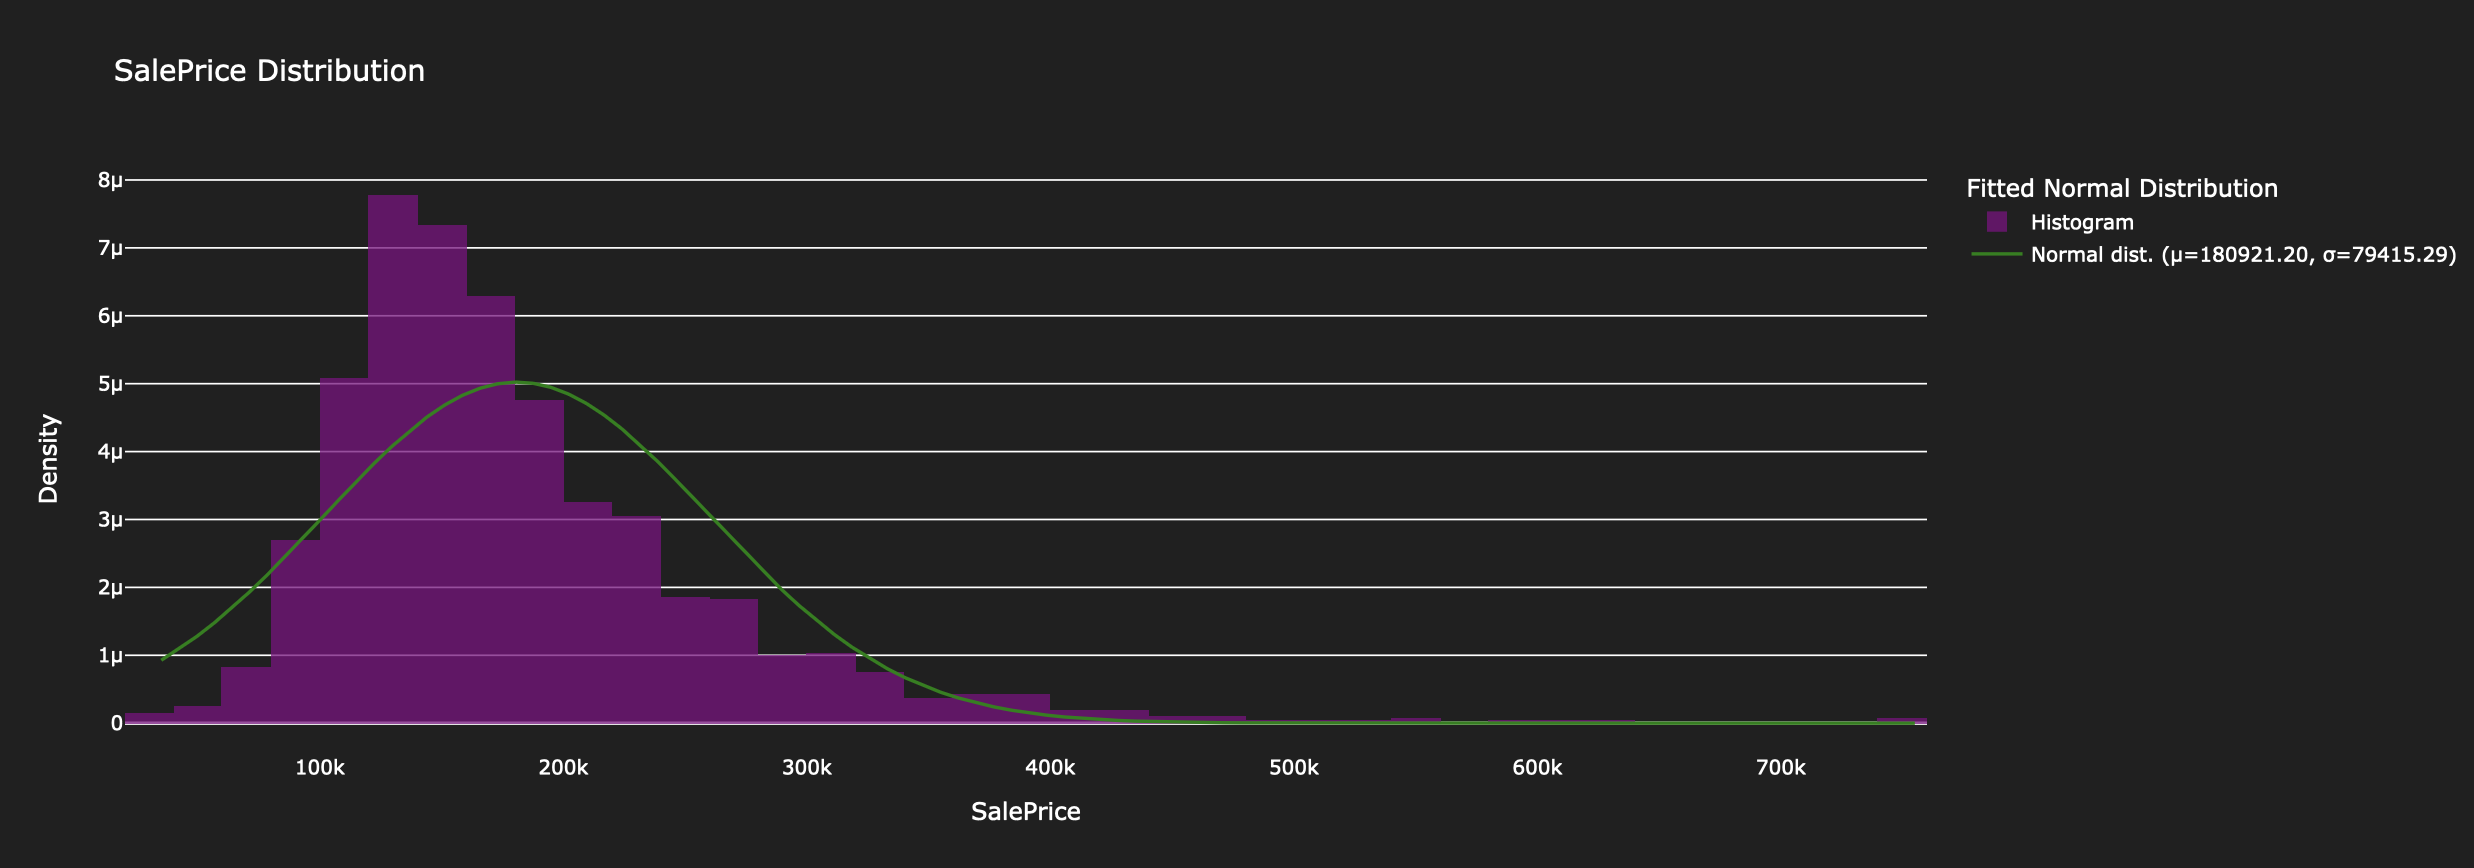

In [99]:
qq_fig.show()

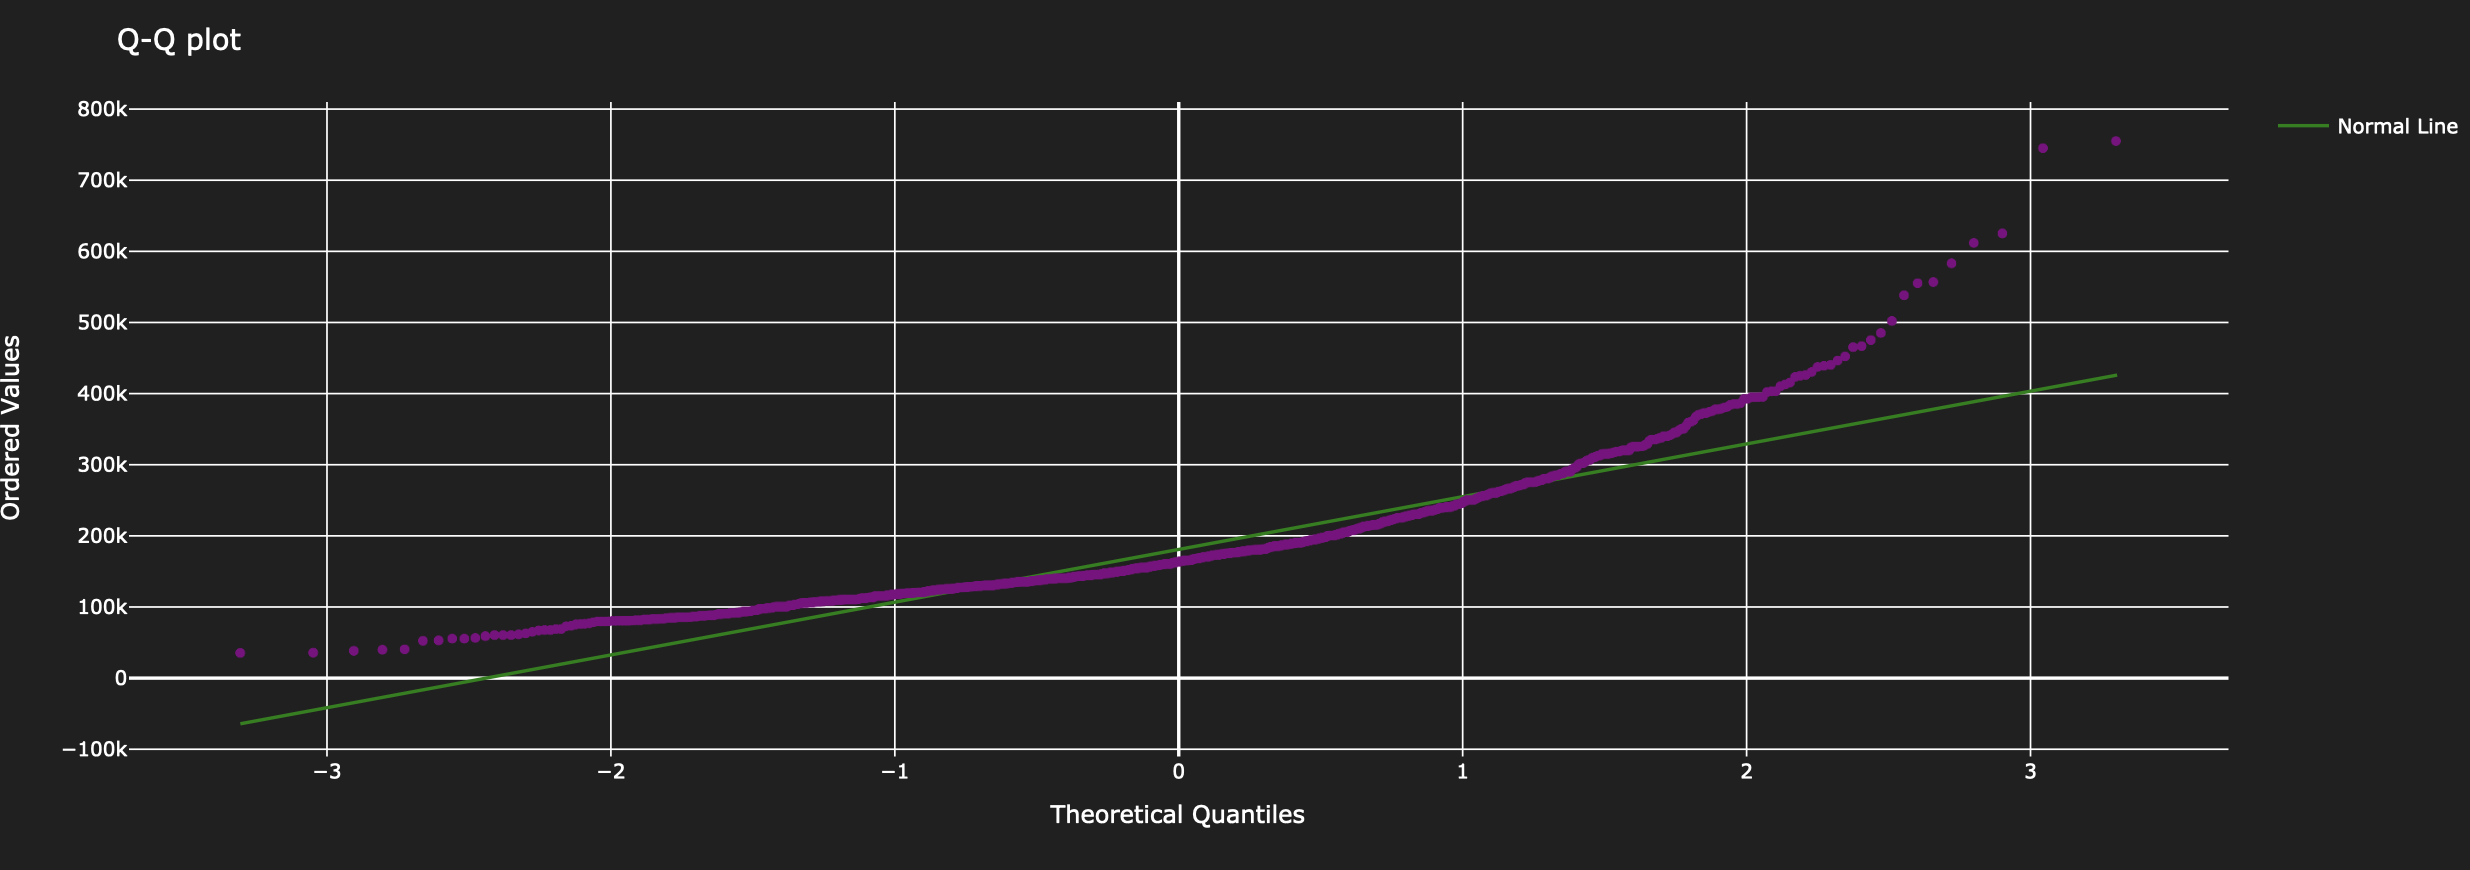

We can see our two graphs (histogram and qq-plot) show the distribution which looks skewed - associated with pricing of house .. we see a ton of right skew in distribution associated with sale price ... we should use log transformation on the data to make it fit a more normal distribution. 


Now, after seeing the data, we should come up with some questions.

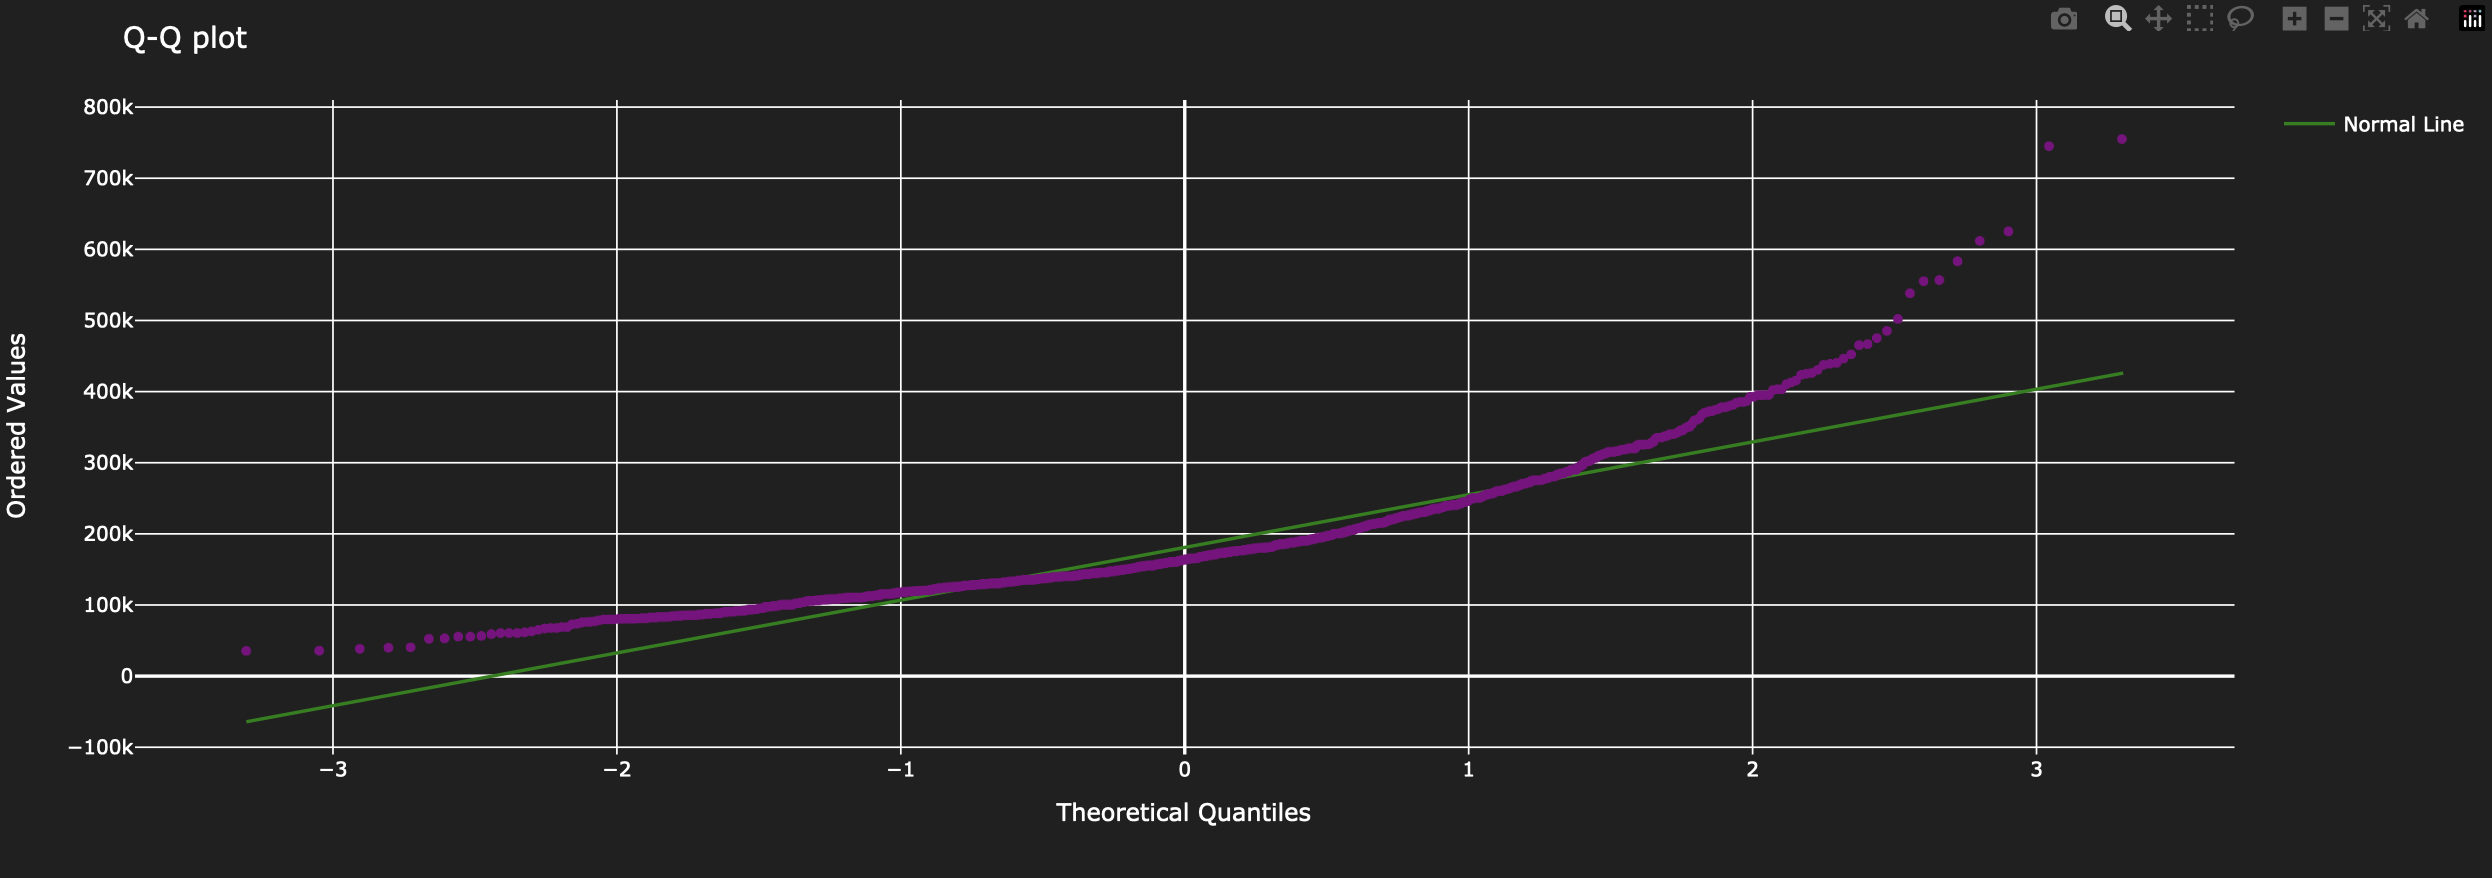

# What questions do we want to ask of the data?

1. Distribution of dwelling types and their relation to sale prices?
2. Does zoning impact sale price?
3. Does street and alley access types effect on sale price?
4. What is the Average sale price by property shape?
5. Is there a Correlation between Property Age and Sale Price
6. Is there a Correlation between Living Area and Sale Price
7. Does price change year to year?

In [100]:
# 1. Distribution of dwelling types and their relation to sale prices
dwelling_types = df['BldgType'].value_counts()
dwelling_prices = df.groupby('BldgType')['SalePrice'].mean()

# Format labels for the second graph
formatted_dwelling_prices = ['$' + f'{value:,.2f}' for value in dwelling_prices.values]

# Create bar charts
fig1 = go.Figure(data=[go.Bar(
    x=dwelling_types.index,
    y=dwelling_types.values,
    marker_color='rgb(76, 175, 80)',
    text=dwelling_types.values,
    textposition='outside',
    width=0.4,
    marker=dict(line=dict(width=2, color='rgba(0,0,0,1)'), opacity=1)
)])
fig1.update_layout(
    title='Distribution of Building Types',
    xaxis_title='Building Type',
    yaxis_title='Count',
    plot_bgcolor='rgba(34, 34, 34, 1)',
    paper_bgcolor='rgba(34, 34, 34, 1)',
    font=dict(color='white')
)

fig2 = go.Figure(data=[go.Bar(
    x=dwelling_prices.index,
    y=dwelling_prices.values,
    marker_color='rgb(156, 39, 176)',
    text=formatted_dwelling_prices,
    textposition='outside',
    width=0.4,
    marker=dict(line=dict(width=2, color='rgba(0,0,0,1)'), opacity=1)
)])
fig2.update_layout(
    title='Average Sale Price by Building Type',
    xaxis_title='Building Type',
    yaxis_title='Price',
    plot_bgcolor='rgba(34, 34, 34, 1)',
    paper_bgcolor='rgba(34, 34, 34, 1)',
    font=dict(color='white')
)

# Show the figures
fig1.show()
## second bar chart below

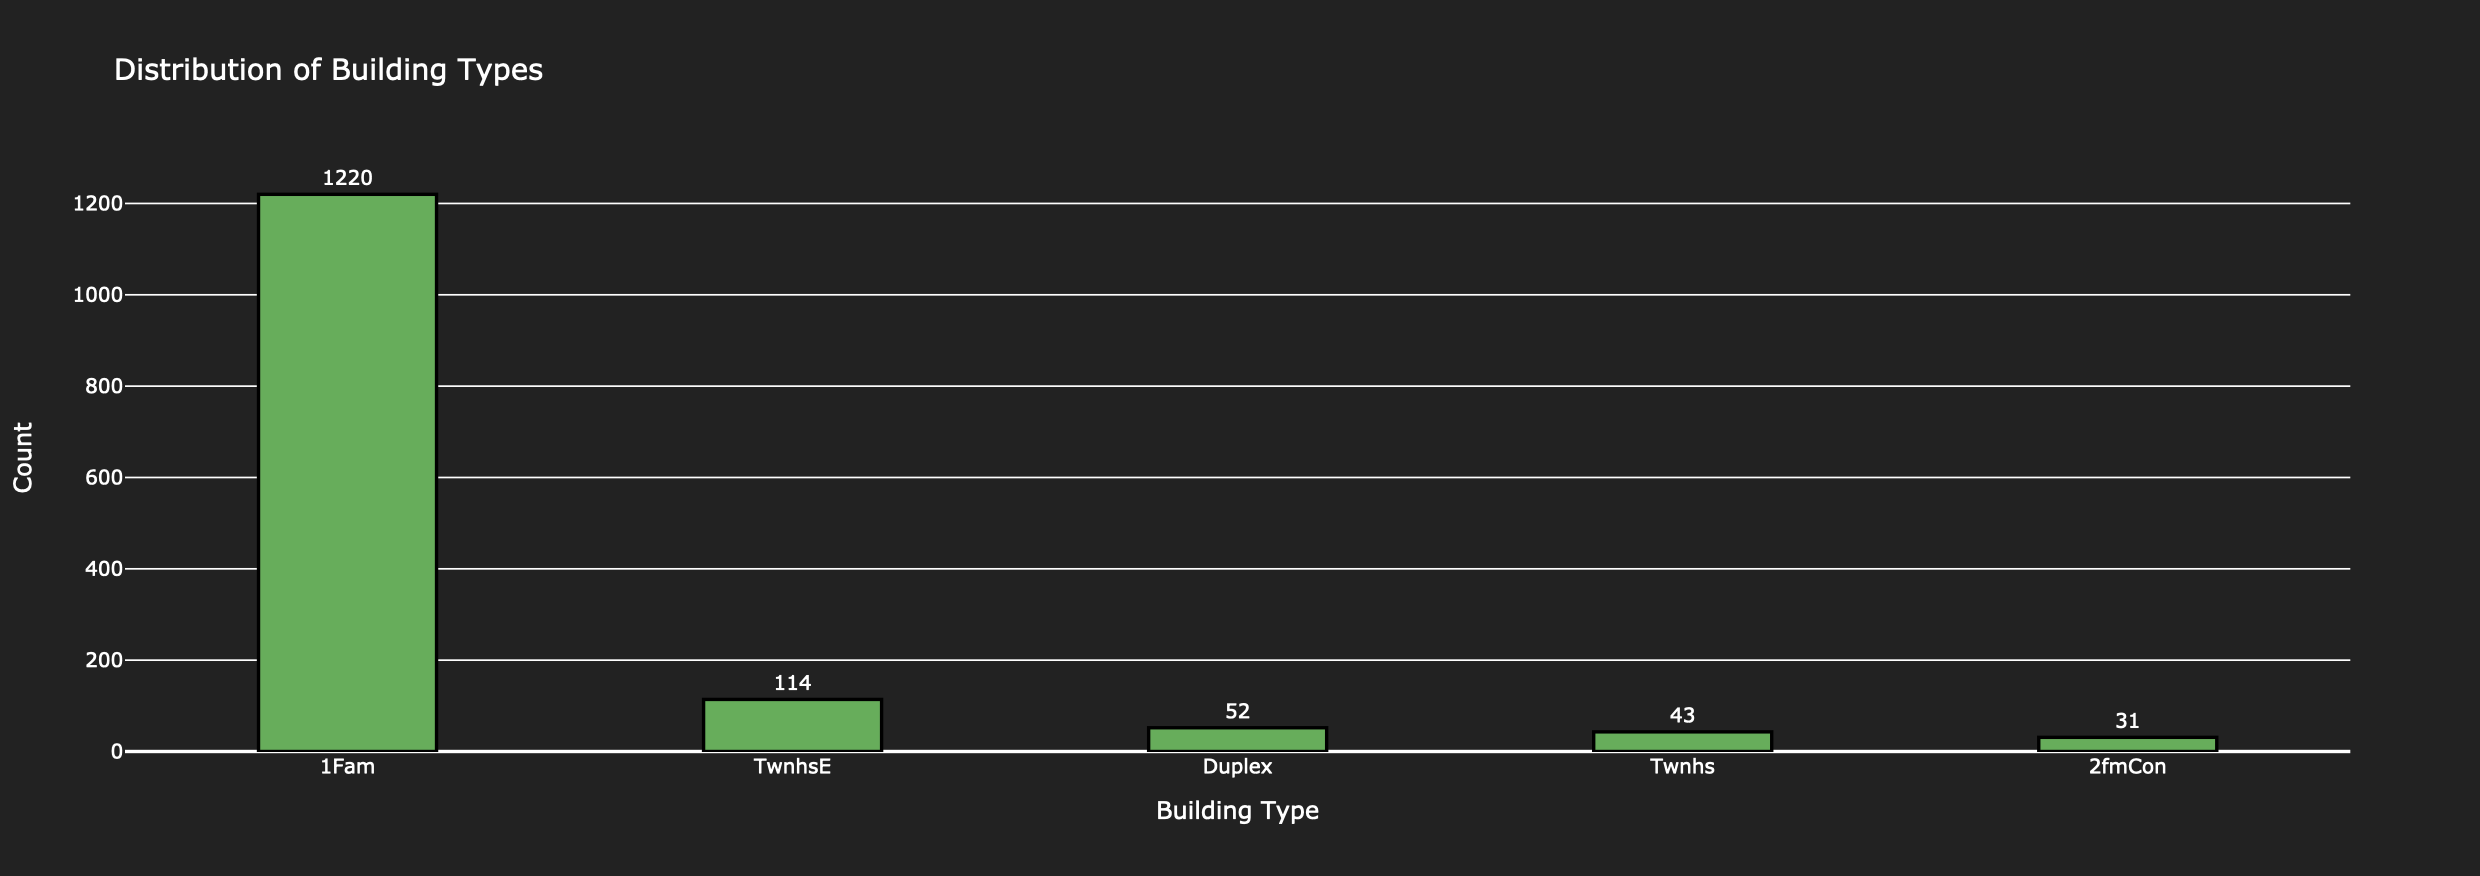

We see the bar chart shows distribution of building types ... we see that the single family homes are most common, then townhouses (end units) being second most common followed by duplexes and normal townhouses. Two family homes are least common.

In [97]:
fig2.show()

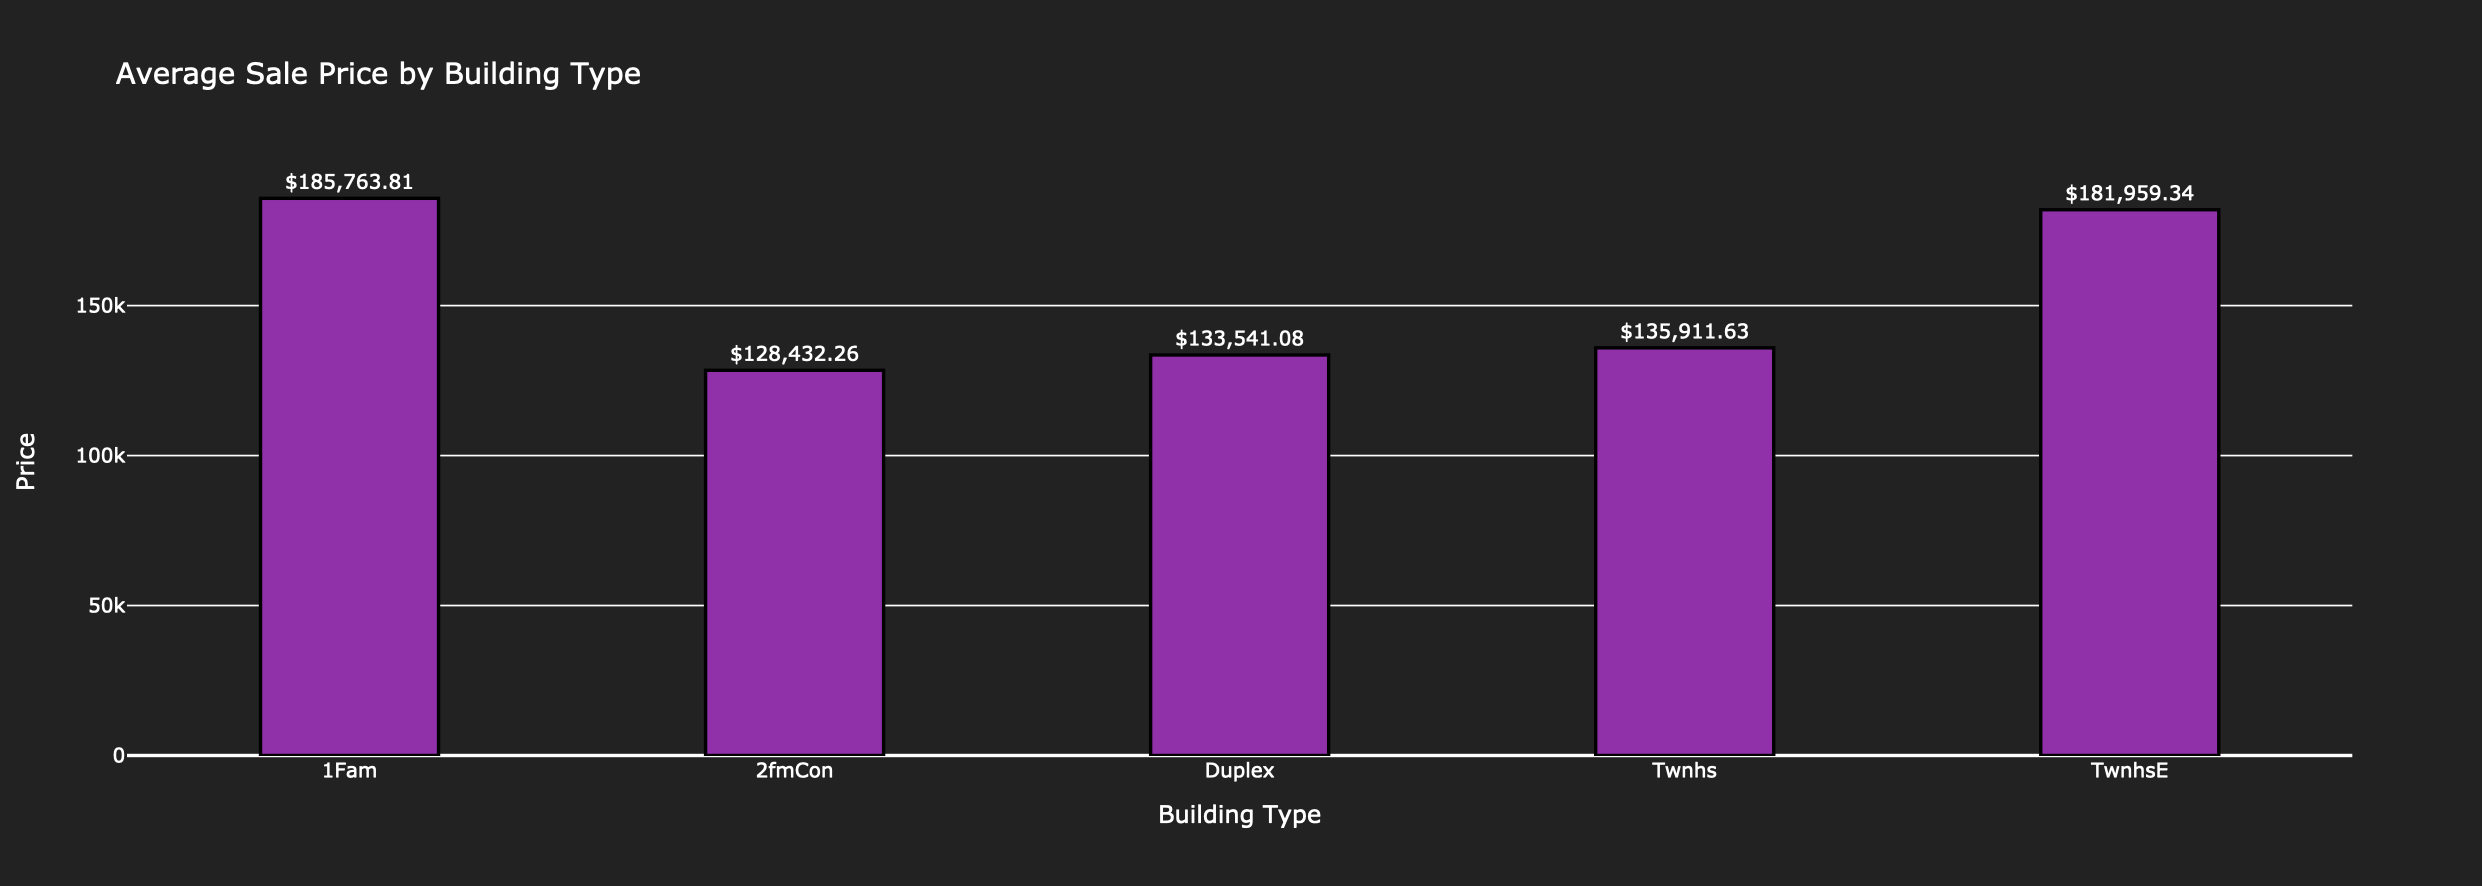

The next bar chart shows average sale price by building type. We see single family homes and townhouse end units are comparably priced (almost equal vals). Its interesting to see townhouse end units with a huge premium compared to normal tounhouses .. this could be due to family preference of a corner home and end unit townhouses being a bit larger compared to standard townhouses.

In [95]:
# 2. How zoning impact on sale price
zoning_prices = df.groupby('MSZoning')['SalePrice'].mean()
fig3 = px.bar(x=zoning_prices.index, y=zoning_prices.values, title='Average Sale Price by Zoning',
              color_discrete_sequence=['purple', 'green'], text=zoning_prices.values,
              template='plotly_dark')

fig3.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig3.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig3.update_xaxes(title='Zoning')
fig3.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

fig3.show()

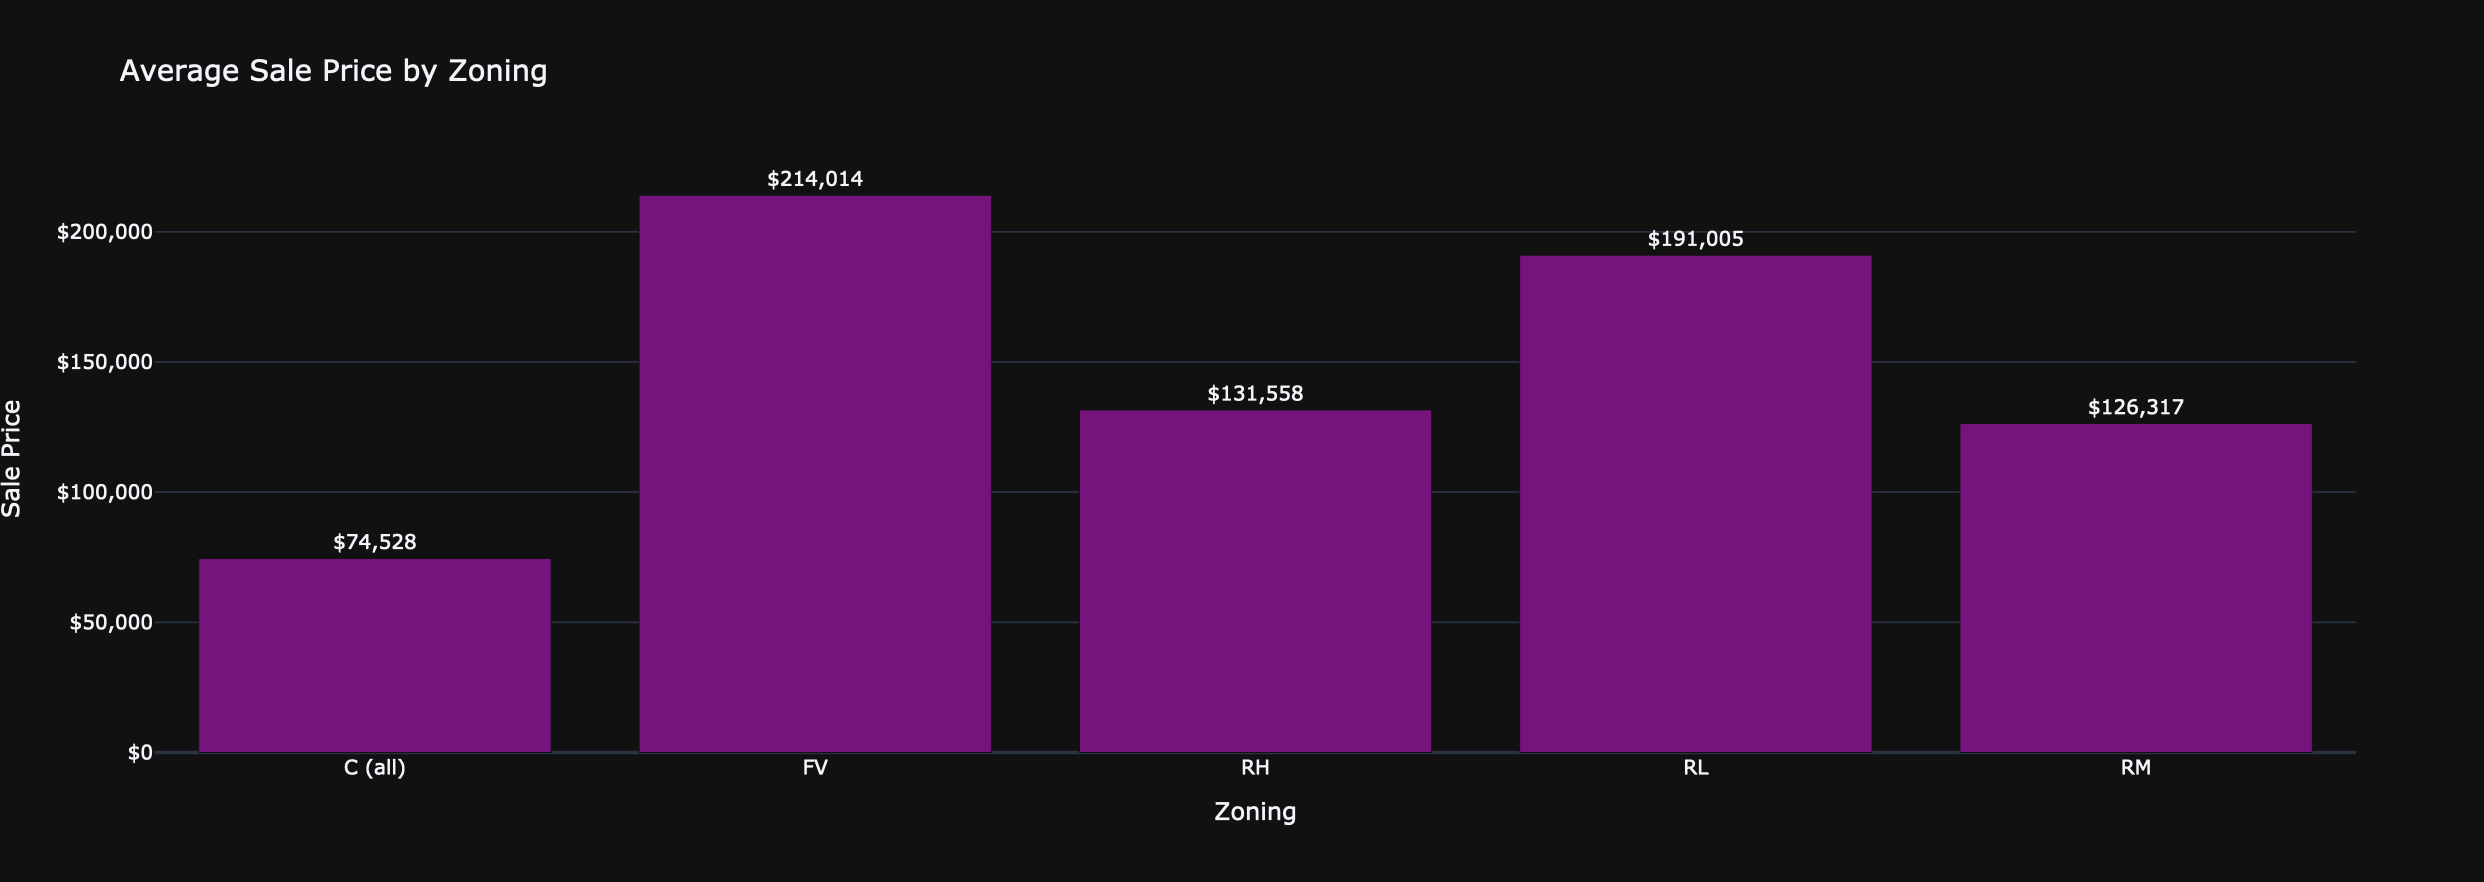

Through this bar chart we see average sale price by zoning.
Chat was useful in this case for improving quality of graphs. 

In [93]:
# 3. Street and alley access types effect on sale price
street_prices = df.groupby('Street')['SalePrice'].mean()
alley_prices = df.groupby('Alley')['SalePrice'].mean()

# Street Prices
colors_street = np.where(street_prices.index == 'Pave', 'purple', 'green')
fig5 = px.bar(x=street_prices.index, y=street_prices.values, title='Average Sale Price by Street Type',
              template='plotly_dark', text=street_prices.values,
              color=colors_street, color_discrete_sequence=['purple', 'green'])

fig5.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig5.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig5.update_xaxes(title='Street Type')
fig5.update_layout(showlegend=False)

# Alley Prices
colors_alley = np.where(alley_prices.index == 'Pave', 'purple', 'green')
fig6 = px.bar(x=alley_prices.index, y=alley_prices.values, title='Average Sale Price by Alley Type',
              template='plotly_dark', text=alley_prices.values,
              color=colors_alley, color_discrete_sequence=['purple', 'green'])

fig6.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig6.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig6.update_xaxes(title='Alley Type')
fig6.update_layout(showlegend=False)

fig5.show()

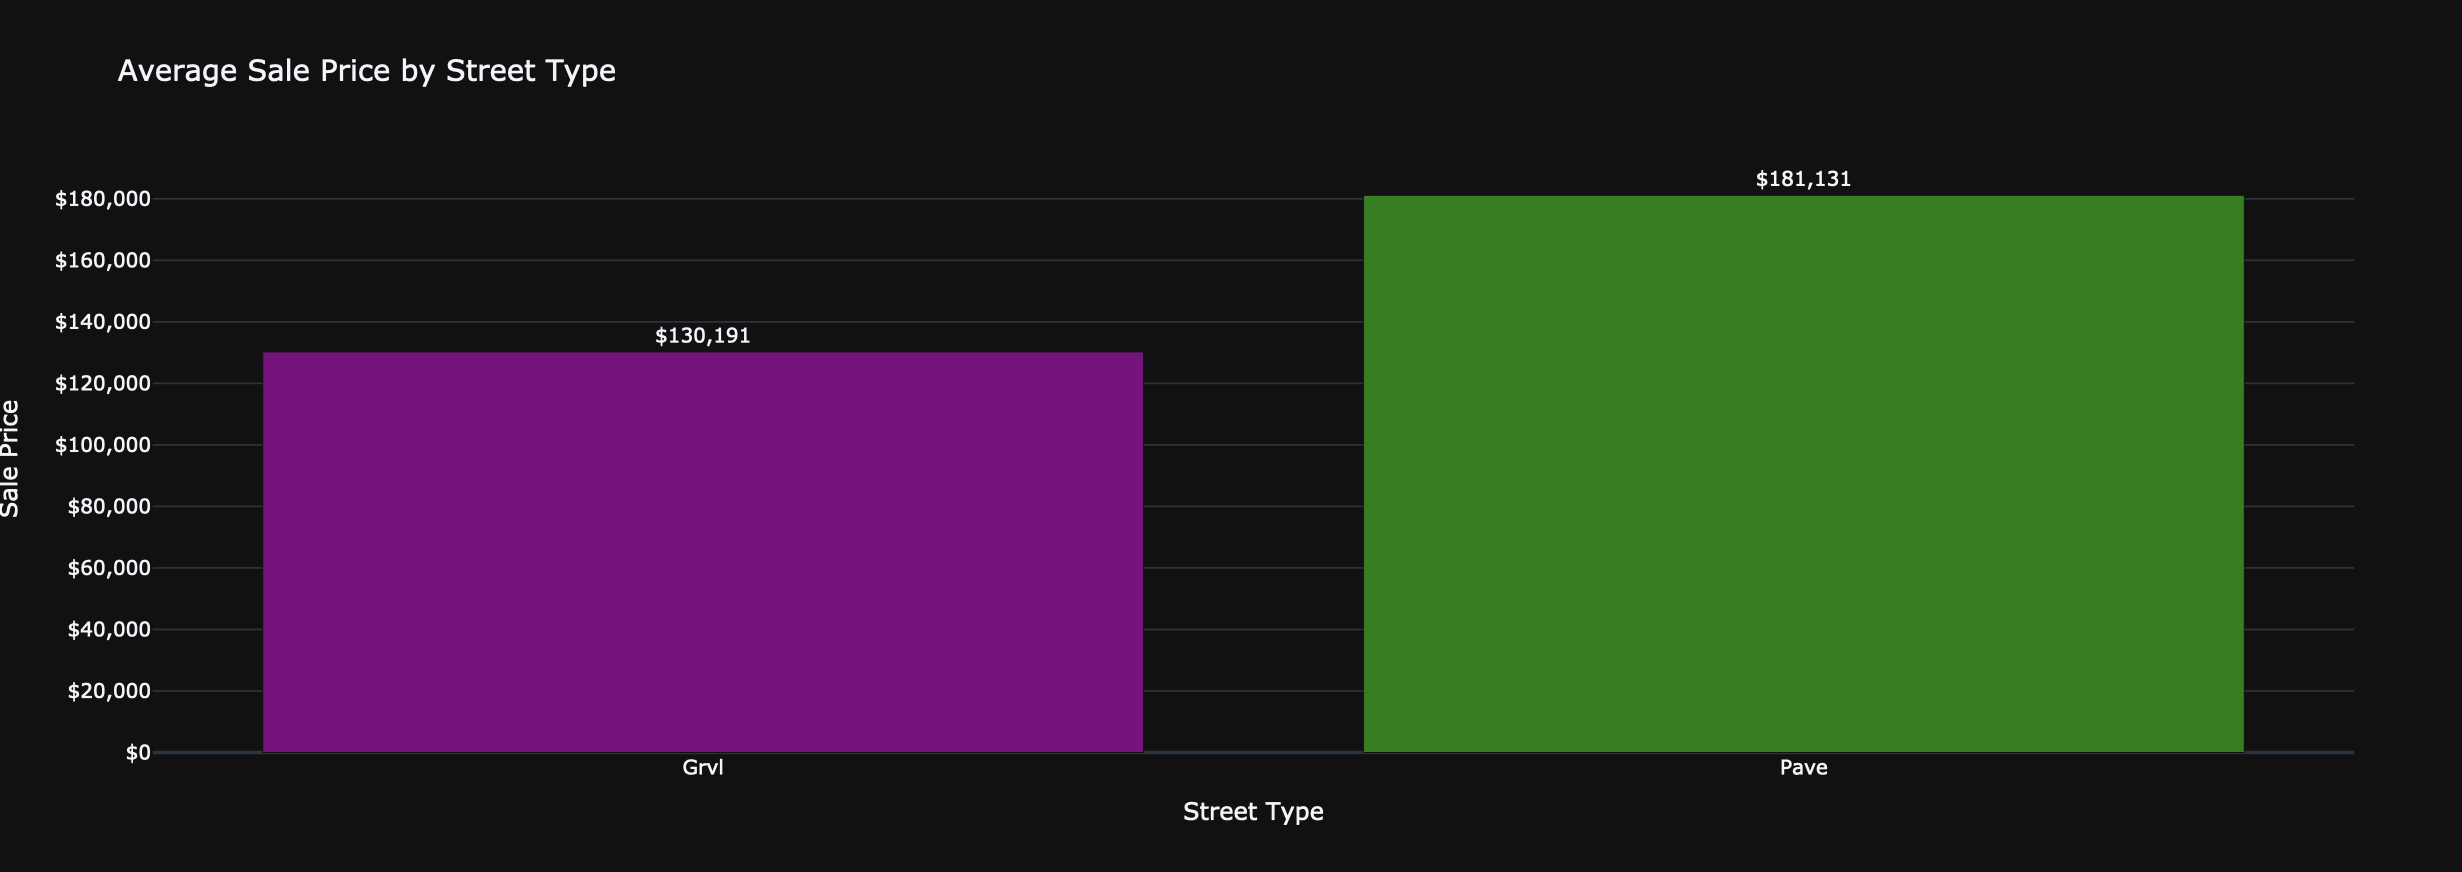

In [94]:
fig6.show()

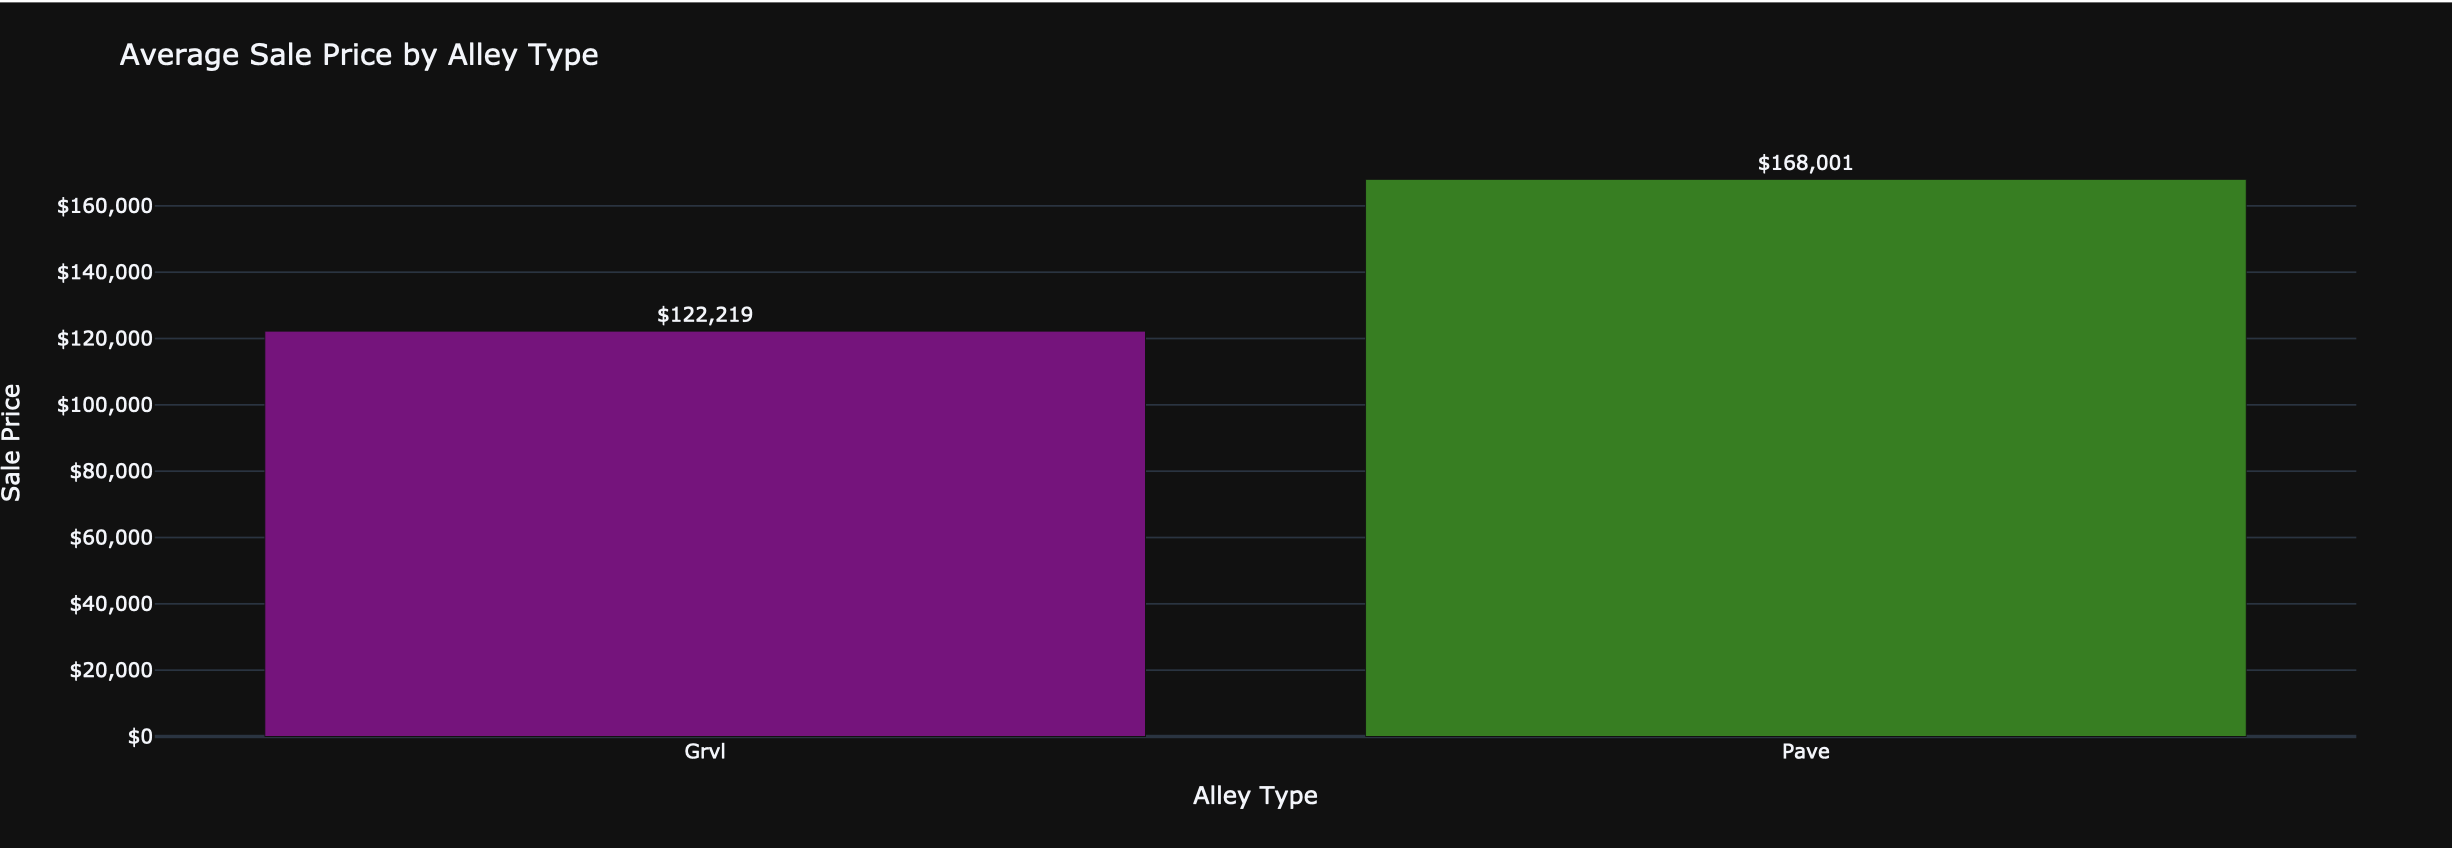

Here, I grouped houses by stree to find average sale price per street. We see paved roads/street are worth more as expected.

In [32]:
# 4. Average sale price by property shape
colors = px.colors.qualitative.Plotly

shape_prices = df.groupby('LotShape')['SalePrice'].mean()
contour_prices = df.groupby('LandContour')['SalePrice'].mean()
# Shape Prices
fig7 = px.bar(x=shape_prices.index, y=shape_prices.values, title='Average Sale Price by Property Shape',
              template='plotly_dark', text=shape_prices.values)

fig7.update_traces(marker_color=colors, texttemplate='$%{text:,.0f}', textposition='outside')
fig7.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig7.update_xaxes(title='Property Shape')
fig7.update_layout(showlegend=False)

# Contour Prices
fig8 = px.bar(x=contour_prices.index, y=contour_prices.values, title='Average Sale Price by Property Contour',
              template='plotly_dark', text=contour_prices.values)

fig8.update_traces(marker_color=colors, texttemplate='$%{text:,.0f}', textposition='outside')
fig8.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig8.update_xaxes(title='Property Contour')
fig8.update_layout(showlegend=False)

fig7.show()

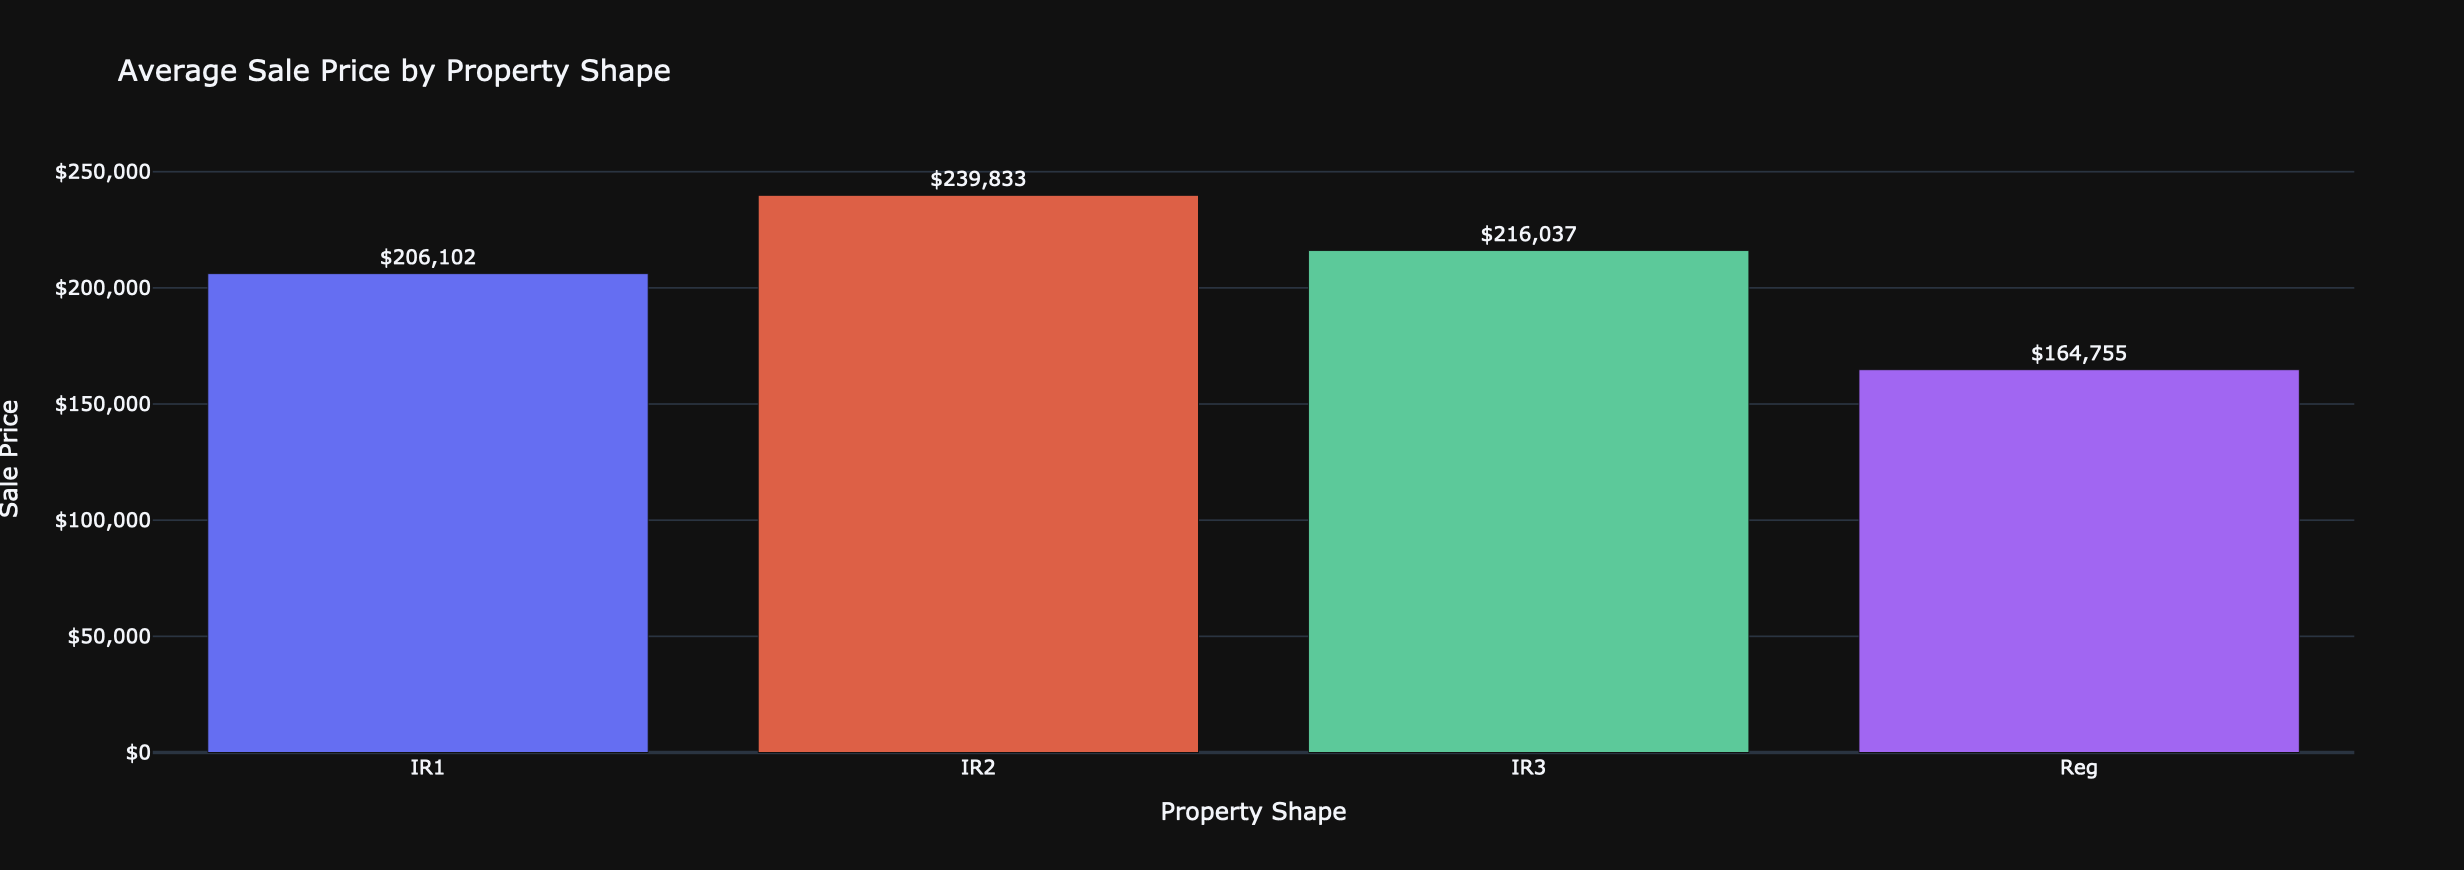

Labels - Reg: Regular, IR1: Slightly irregular, IR2: Moderately irregular, IR3: Irregular (for below graph legend)
We see IR2 has highest average selling price surprisingly.

In [33]:
fig8.show()

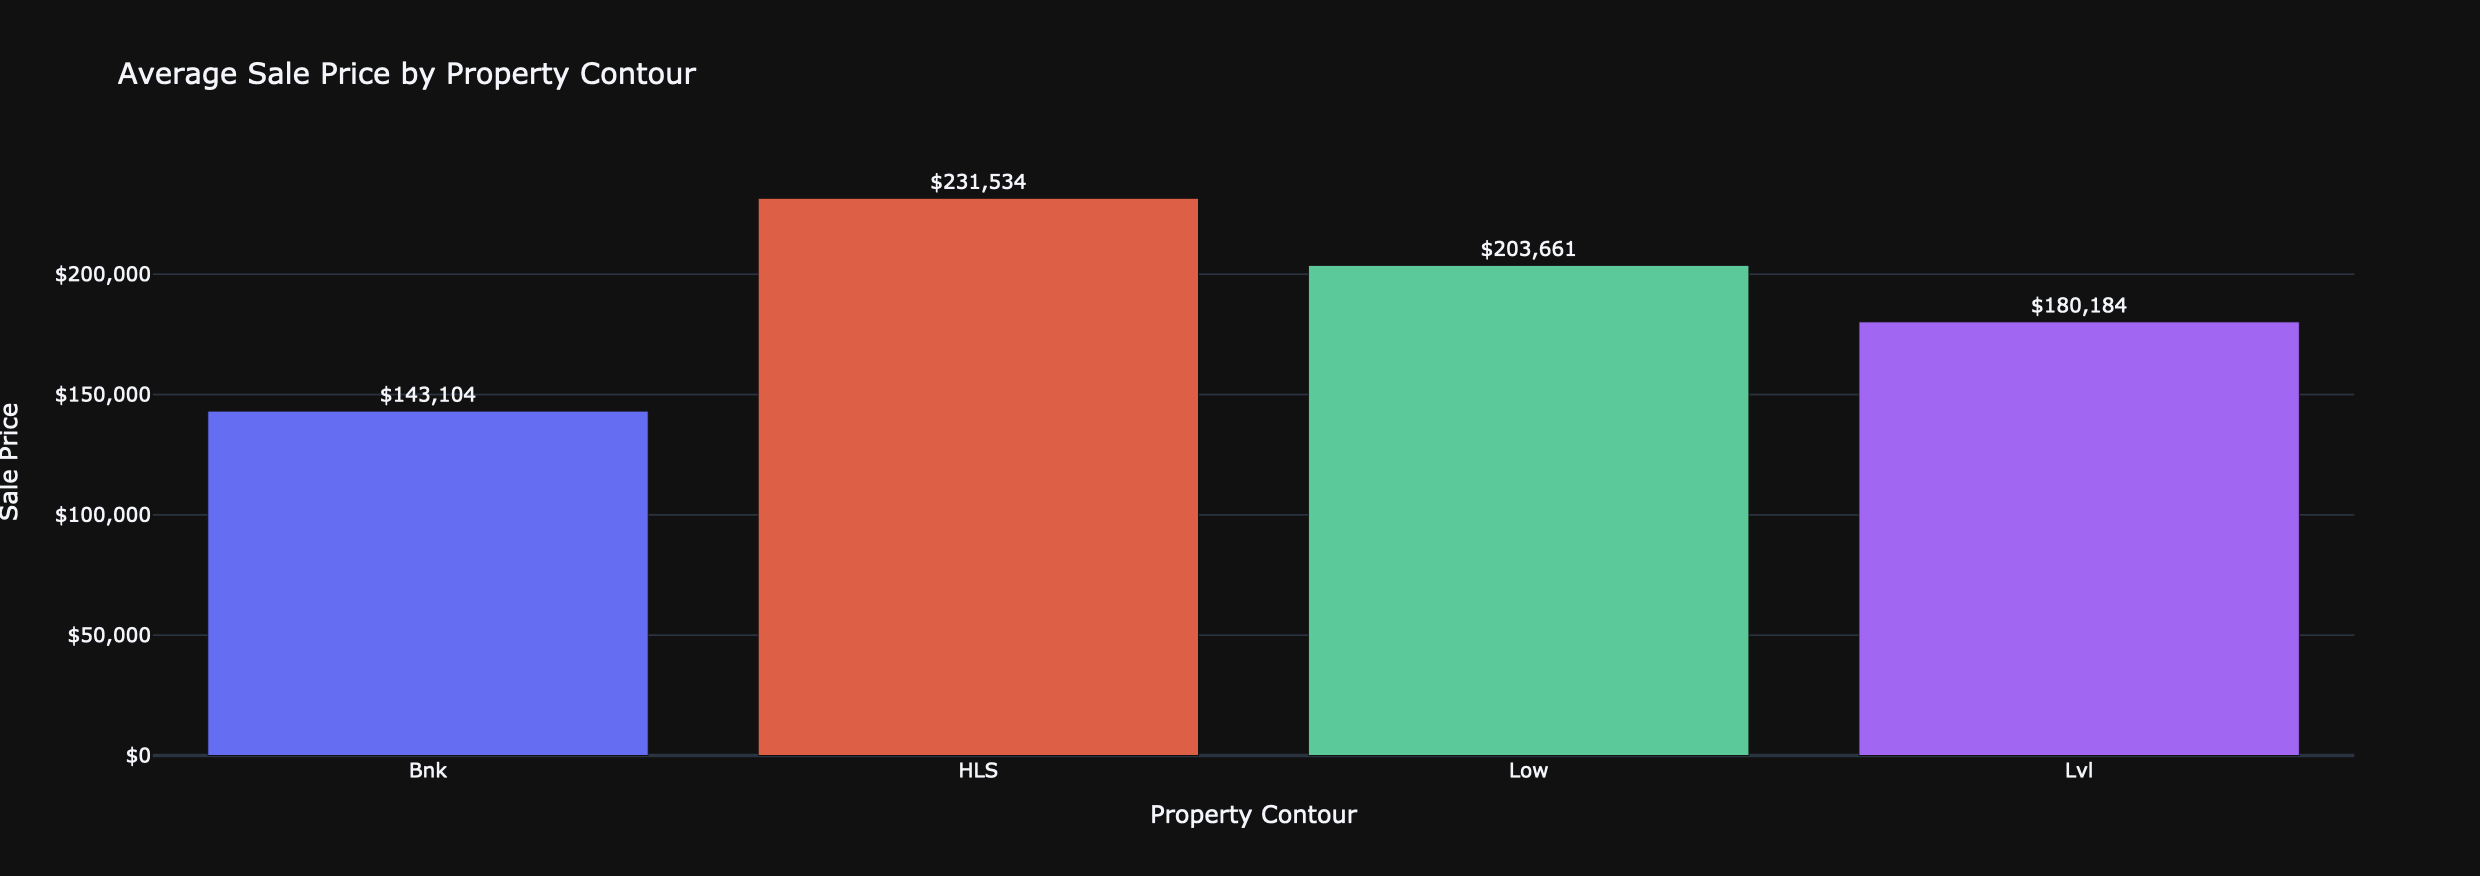

In [92]:
# 5. Calculate Property Age
df['PropertyAge'] = df['YrSold'] - df['YearBuilt']

# Calculate Correlation between Property Age and Sale Price
age_price_corr = df['PropertyAge'].corr(df['SalePrice'])
print(f'Correlation between Property Age and Sale Price: {age_price_corr}')

# Create a scatter plot to visualize the relationship between Property Age and Sale Price
fig9 = px.scatter(df, x='PropertyAge', y='SalePrice', title='Property Age vs Sale Price', color='PropertyAge', color_continuous_scale=px.colors.sequential.Purp)

fig9.update_layout(plot_bgcolor='rgb(30,30,30)', paper_bgcolor='rgb(30,30,30)', font=dict(color='white'))

fig9.show()

Correlation between Property Age and Sale Price: -0.523350417546816


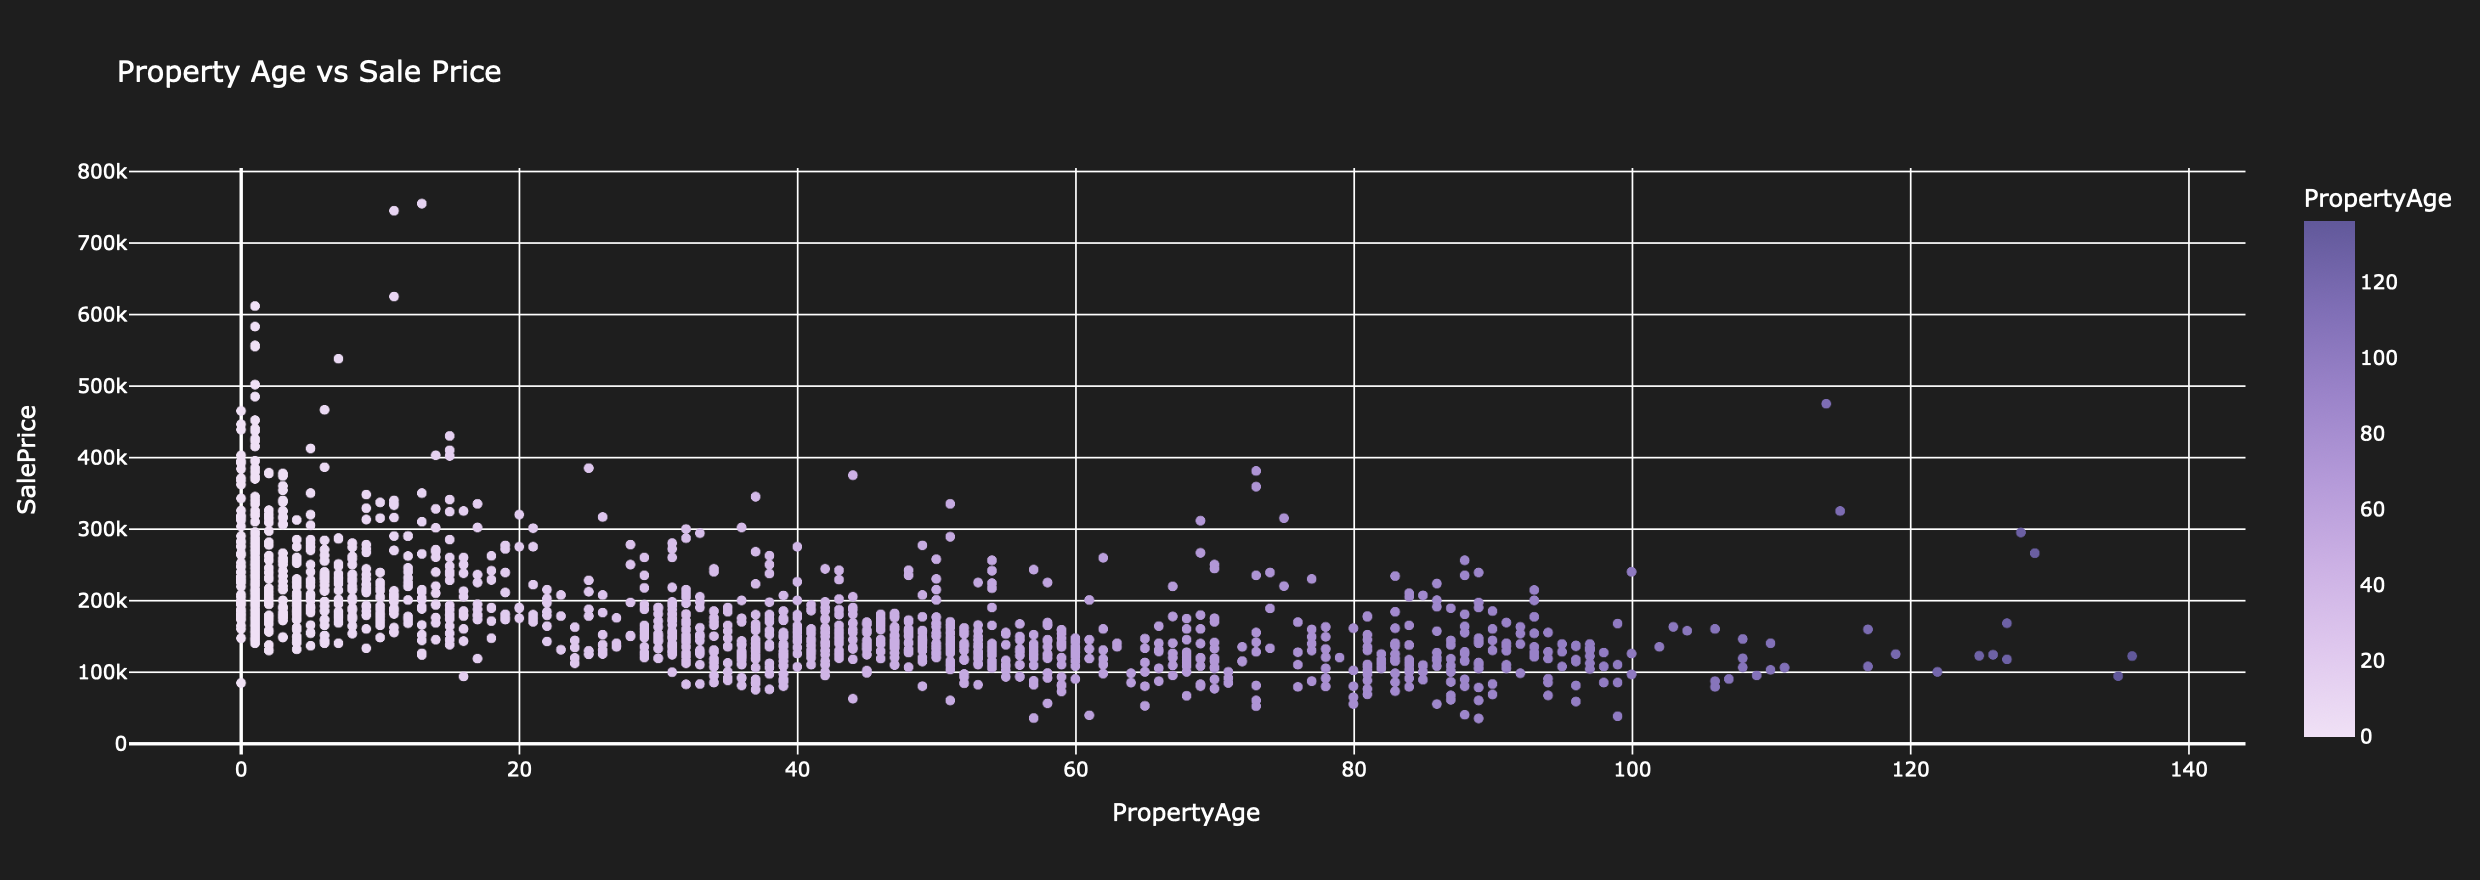

I created a new variable: property age (year sold - year built). 
We used a core plot here and see a downward trend, seeing that older houses are sold for less. 

In [35]:
# 6. Calculate Correlation between Living Area and Sale Price
living_area_price_corr = df['GrLivArea'].corr(df['SalePrice'])
print(f'Correlation between Living Area (above grade) and Sale Price: {living_area_price_corr}')

# Create a scatter plot to visualize the relationship between Living Area and Sale Price
fig10 = px.scatter(df, x='GrLivArea', y='SalePrice', title='Living Area (above grade) vs Sale Price', color='GrLivArea', color_continuous_scale=px.colors.sequential.Purp)

fig10.update_layout(plot_bgcolor='rgb(30,30,30)', paper_bgcolor='rgb(30,30,30)', font=dict(color='white'))

fig10.show()

Correlation between Living Area (above grade) and Sale Price: 0.7086244776126523


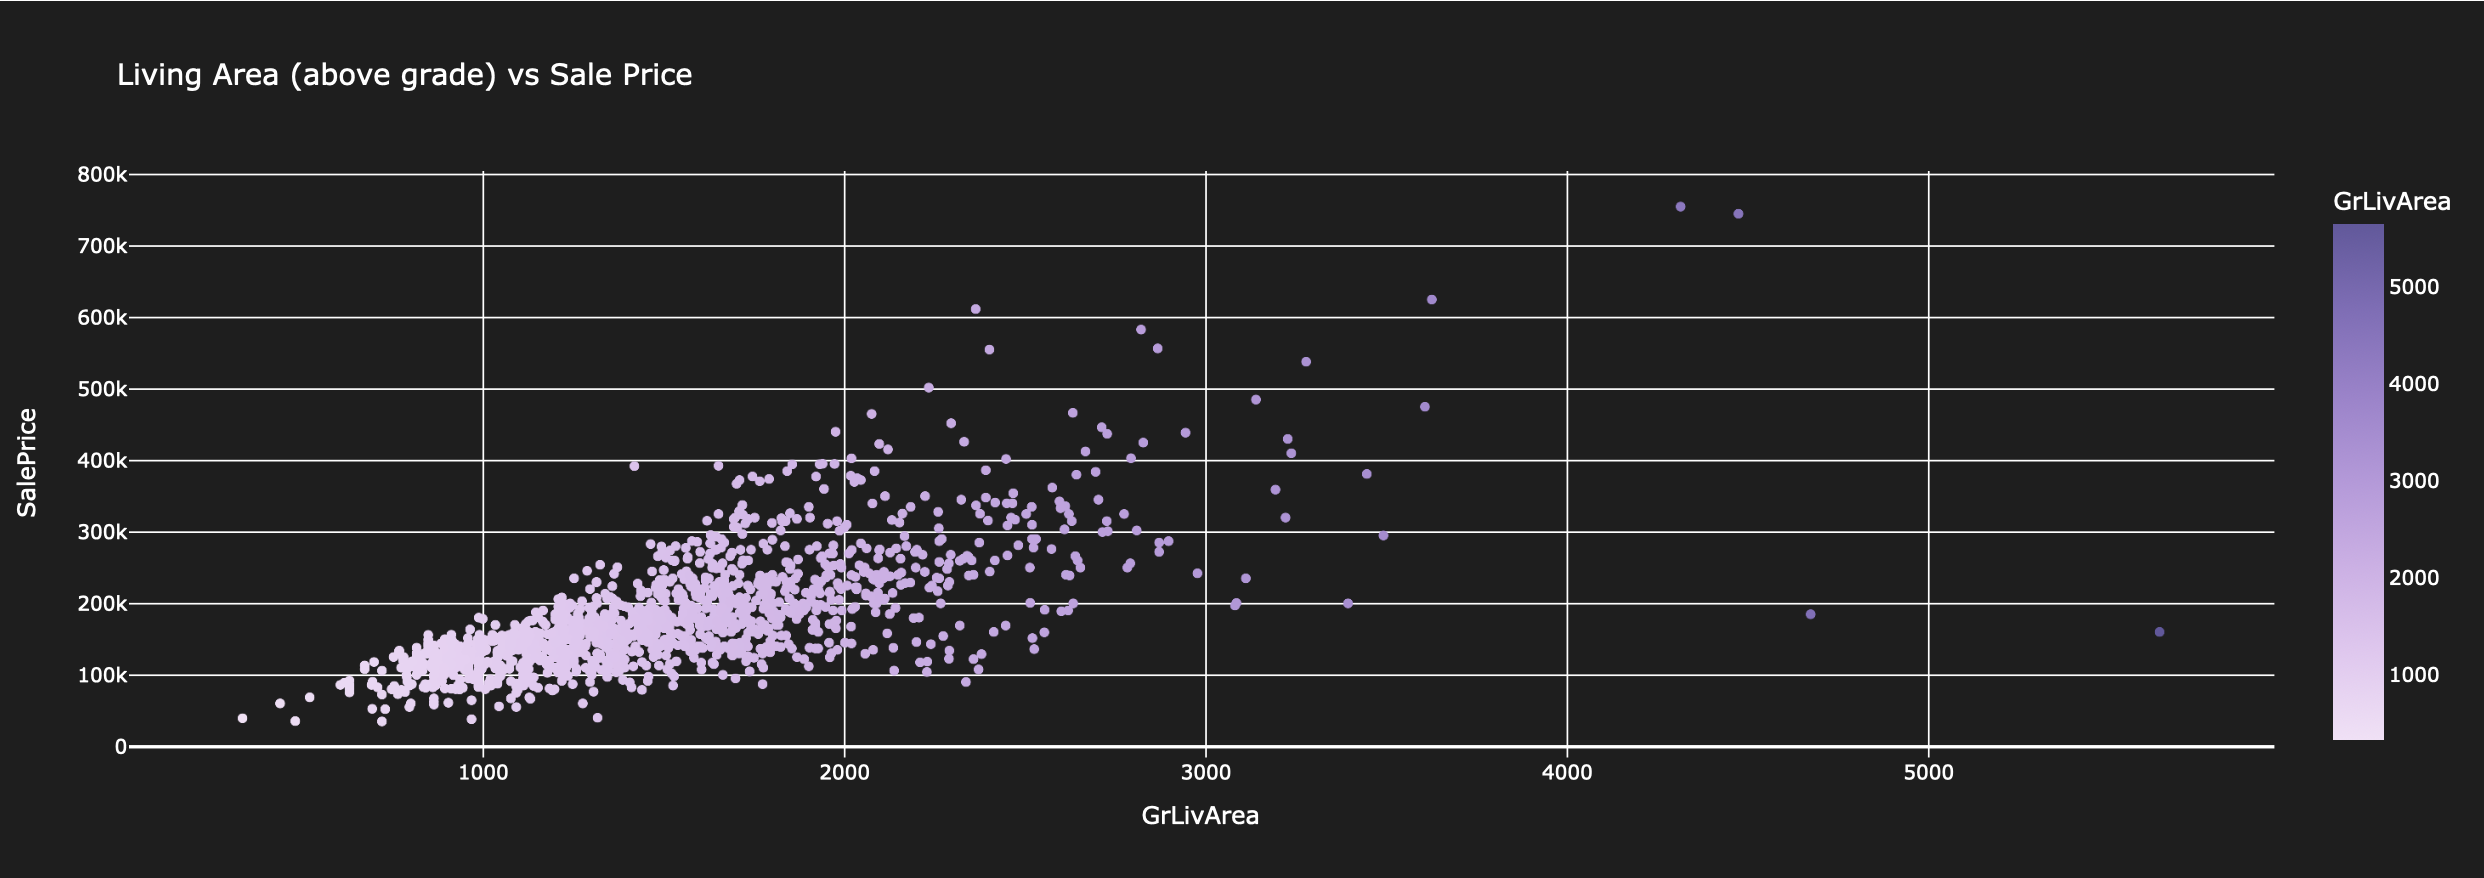

Living area vs sale price shows the better the living area, the better the sale price.

In [36]:
# 7. Box plot of price over the years
yearly_avg_sale_price = df.groupby('YrSold')['SalePrice'].mean()

fig13 = px.box(df, x='YrSold', y='SalePrice', title='Sale Price Trends Over the Years',
               points=False, color_discrete_sequence=['green'])

fig13.add_trace(px.line(x=yearly_avg_sale_price.index, y=yearly_avg_sale_price.values).data[0])

fig13.update_traces(line=dict(color='purple', width=4), selector=dict(type='scatter', mode='lines'))

for year, avg_price in yearly_avg_sale_price.items():
    fig13.add_annotation(
        x=year,
        y=avg_price,
        text=f"{avg_price:,.0f}",
        font=dict(color='white'),
        showarrow=False,
        bgcolor='rgba(128, 0, 128, 0.6)'
    )

fig13.update_layout(
    plot_bgcolor='rgb(30,30,30)',
    paper_bgcolor='rgb(30,30,30)',
    font=dict(color='white'),
    xaxis_title='Year Sold',
    yaxis_title='Sale Price'
)

fig13.show()

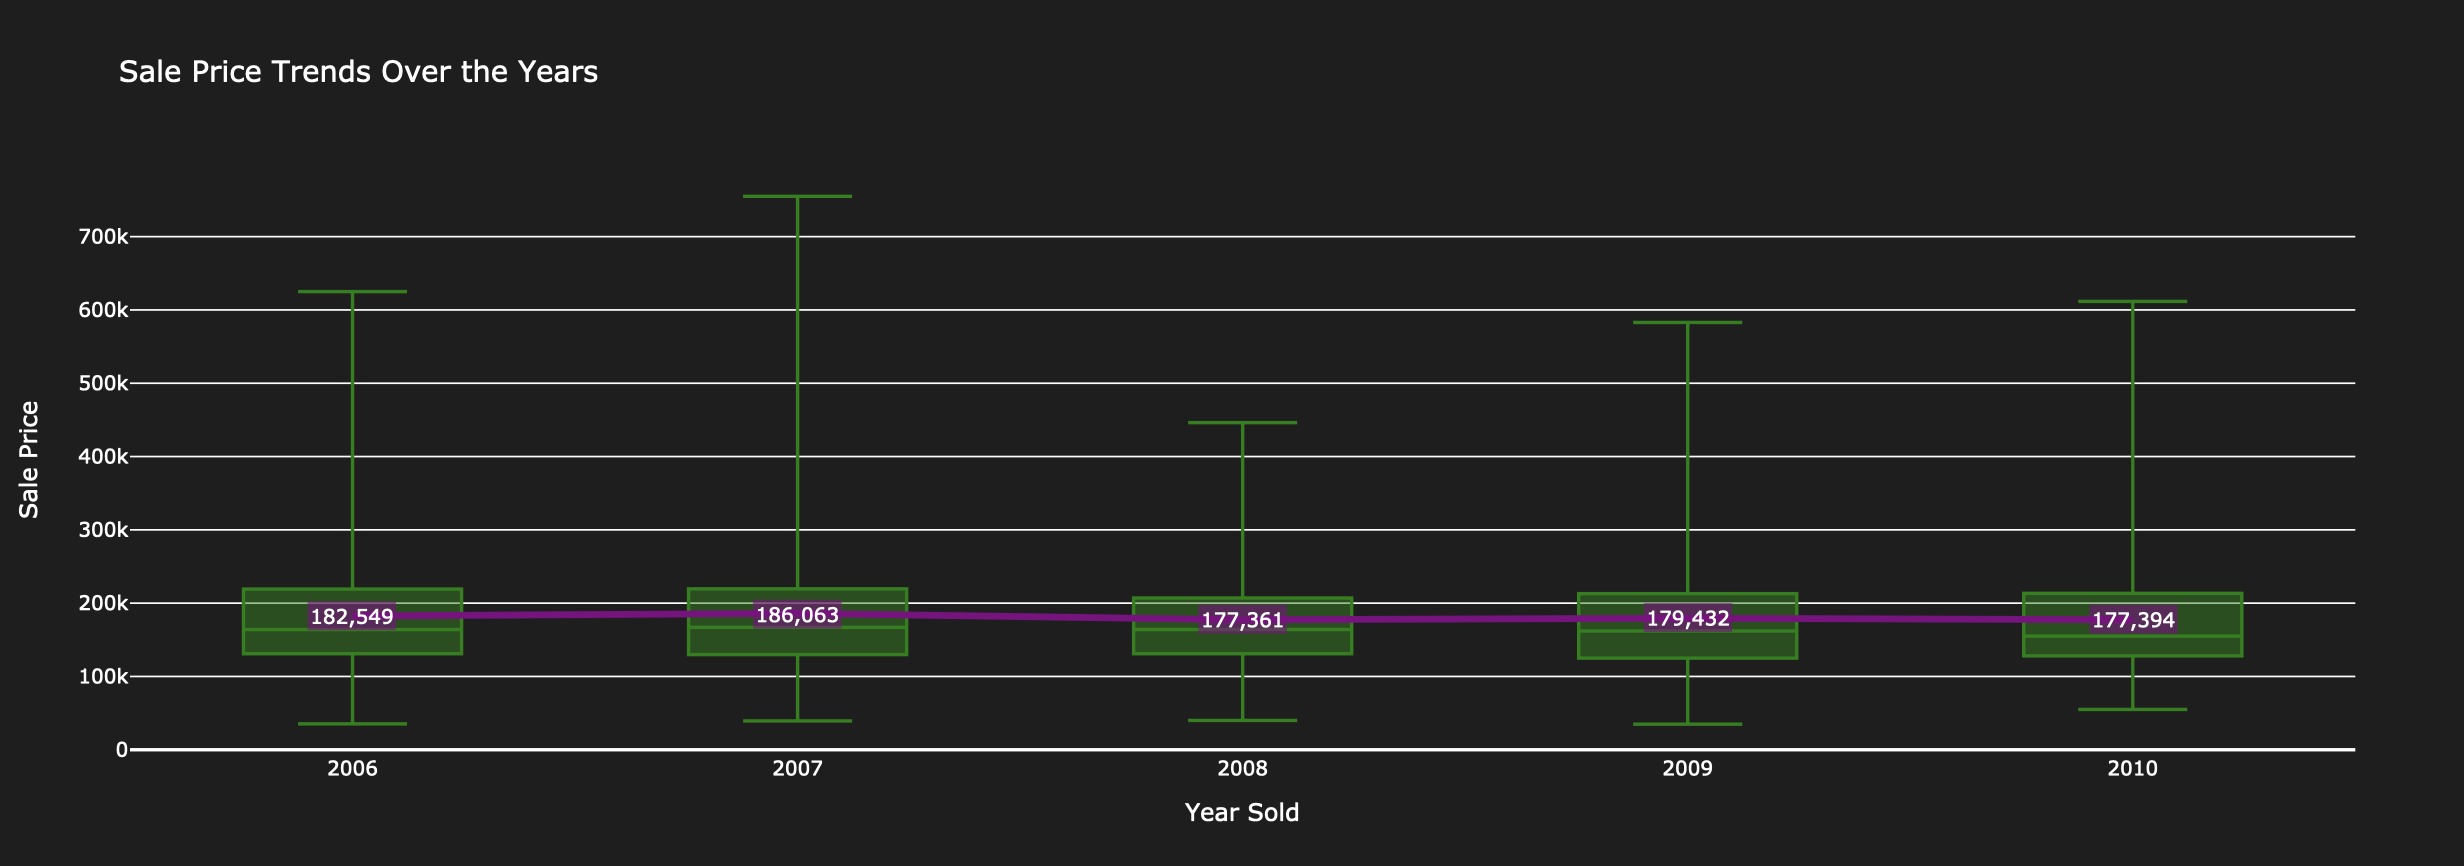

Seeing the box plots of housing sale prices over the years, we see massive variation in 2007 of housing prices (decreased due to financial crisis etc). 

We can extract a lot of information from this. Each individual year (YearBuilt) is a continuous variable, whereas YearSold might not be as strong an indicator. Continuous variables often provide more nuanced insights compared to categorical variables, which are treated as independent events. Nevertheless, we can still observe how housing prices vary across different years and see the range of prices for each year.

# Creating a Data Pipeline
Why do this? - So we have consistent infrastructure for transforming the test set

Goal - To create infrastructure that lets us make changes without breaking everything 

Now let’s clean the data and make it usable for our model. We’ve already created new variables. Next, we may want to normalize or scale the data depending on the model, one-hot encode categorical variables, and impute data as needed.


Ml process: different ways to scale, impute, encode
- Scale - to bring cts vars in specific range
- Impute missing vals - missing values must be handled appropriately to avoid errors in modeling.
- Encoding categorical data - as catg. vars. need to be converted into numeric form for most ML models.


Note: The choice of scaling, imputation, and encoding methods depends on the model we are using. Proper preprocessing ensures that the model learns effectively and generalizes well.
For example:
- Tree-based models (Random Forest, XGBoost) often do not require scaling.
- Linear models and neural networks usually benefit from scaling.

In [37]:
from sklearn.compose import ColumnTransformer ## to apply diff. pipelines to diff. columns (numerical vs categorical)
from sklearn.pipeline import Pipeline ## pipeline 2 chain mult. preprocessing steps tgthr..so don’t manually apply each step.
from sklearn.impute import SimpleImputer ## fills missing values (NaN) in your data.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
## StandardScaler → standardizes numeric features (mean = 0, std = 1)
## converts categorical variables into dummy/indicator variables.

Feature Scaling
Primarily two types of feature scaling methods
1. Min-max scaling (normalization)
   (value - min) / (max - min)
   Sklearn provides a class method MinMaxScaler for this
2. Standardization
   (value - mean) / std
   Sklearn provides a class called StandardScaler for this 

In this notebook, we will be using Standardization!

Scikit-learn Design

Primarily there are three types of objects

1. Estimators - it estimates some parameters based on a dataset eg imputer. It has a fit method and transform method. The fit method fits the dataset and calculates parameters.
   
2. Transformers - transform method takes input and returns output based on the learnings from fit(). It also has a convenience function called fit_transform() which fits and then transforms.

    
3. Predictors - LinearRegresiion model is an example of predictor. fit() and predict() are two common functions. It also gives score function which will evaluate the predictions.


Now we will set up preprocessing pipelines for both numerical and categorical data using scikit-learn, so our dataset is ready for machine learning models

In [40]:
# Define transformers for numerical

## for numerical data we will fill missing vals with mean (impute) and then scale
## we first impute all numeric data with average (replace missing with col means)
## we scale since it is important for models sensitive to feature magnitudes (e.g., linear regression, neural networks)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Define transformers for categorical columns

## for categorical data we will impute all null values as a constant (so if null then treat as new category: 'missing')
## then we will onehotecode -- converts each category into a separate dummy column with 0/1 values.
## categorical data: fill missing values → create dummy variables.

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse = False))
])


!! Pipelines let you chain multiple preprocessing steps together. Data flows through each step—like imputation, scaling, or encoding—and outputs a clean, transformed dataset. Using pipelines is a clean and organized way to prepare data, ensuring that the same steps applied to the training data can be reliably repeated on new or test data. This makes the code scalable, consistent, and ready for modeling.


In [41]:

# Update categorical and numerical columns (split data into numerical/categorical)
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Remove target variable from numerical columns .. drop dependent variable
numerical_columns = numerical_columns.drop('SalePrice')

# Combine transformers using ColumnTransformer ... let's you choose which columns to adjust
## we want numerical transformer to adjust numerical and catg. for catg
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ],remainder = 'passthrough')

# Create a pipeline with the preprocessor 
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)])

## Add trained model that you want pipelien to go through
## i like to preprocess data then test the model then put it in a pipeline.

# Apply the pipeline to your dataset
X = df.drop('SalePrice', axis=1)
y = np.log(df['SalePrice']) #normalize dependent variable w/ log since we found this to be skewed earlier
X_preprocessed = pipeline.fit_transform(X) 

In the code above we fit and transform our data (labelled: X_preprocessed) using the pipeline we created above (labelled: pipeline).

The pipeline runs the preprocessor (labelled: 'preprocessor'), applying all the steps we defined - imputation, scaling for numerical data, and imputation plus one-hot encoding for categorical data.

This ensures our data is fully cleaned and ready for modeling. Later, as we do more feature engineering or data manipulation, we can go back and adjust the pipeline if needed to reflect any new transformations.

# MODEL TRAINING BELOW!
Different types of advance regression we will be using will be: linear regression, random forest, XG Boost, MLP (neaural net but done on CPU not using tensorflow and Keras)


What is each and when to use? 
- Linear Regression: to show linear relationships between features and target. It is fast, interpretable, good for small to medium datasets but struggles with nonlinear relationships and complex interactions. 
- Random Forest: is an ensemble of decision trees combining predictions to reduce variance and improve accuracy. It handles nonlinear relationships and feature interactions. It is robust, minimal preprocessing, and works with mixed data types (ie categorical and numerical). It is less interpretable than linear regression, slower on very large datasets.
- XGBoost: It is gradient boosting of decision trees; sequentially builds trees to correct previous errors. It is used for complex, nonlinear data with high predictive accuracy, handles missing values and flexible with hyperparameter tuning. It is great for competitions. However, it is sensitive to hyperparameters and slower to train than Random Forest.
- MLP (neural network): It is a multi-layer perceptron and can learn complex nonlinear relationships. It is flexible, can approximate any function. However it is slower on CPU, less interpretable, needs scaling and sensitive to hyperparameters.

## Fit and Parameter Tune models 
- We explore some different types of models here and see how they work (or don't work)

Steps of our block of code below:
1. Splits data into training and testing sets.
2. Defines three models (linear, tree-based, boosting).
3. Sets up hyperparameter grids for each model.
4. Uses 3-fold cross-validation to evaluate each combination.
5. Finds the best hyperparameters for each model and computes the best RMSE.

In [54]:
from sklearn.linear_model import LinearRegression  
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
## above I imported the three models I will be training; LinearRegression, RandomForestRegressor, XGBRegressor

from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
## GridSearchCV → searches over a grid of hyperparameters to find the best combination.
## KFold → for cross-validation, splitting the data into folds to evaluate model performance.
## train_test_split → splits your data into training and testing sets.


# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42) 
##Features (after preprocessing pipeline) , y = Target variable, 0.2 = 20% of data reserved for testing, 42 = ensure reproducibility

# Define the models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Define the hyperparameter grids for each model (w/ a dictionary of model instances, each with a name)
## Lin regression has no pars to tune
## Random Forest: n_est = num. of trees in forest, max-dep = max depth of each tree, min = min samples required to split a node
## XGBoost = n_est = num of boosting rounds, lean_rate = step size shrinkage, max_dept = tree depth
param_grids = {
    'LinearRegression': {},
    'RandomForest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 10, 30],
        'min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 6, 10],
    }
}

# 3-fold cross-validation
## each model is trained on 2 folds and validated on the 3rd fold, repeated 3 times.
## Split training data into 3 folds, Shuffle data before splitting, reproducible splits 
cv = KFold(n_splits=3, shuffle=True, random_state=42)


Explanation of our code for training/tuning the model below

- grids = {} → initialize dictionary to store trained GridSearchCV objects.
- Loop through each model:
    Initialize GridSearchCV with:
    estimator=model → the current model to train
    param_grid → hyperparameter options
    cv → cross-validation strategy
    scoring='neg_mean_squared_error' → metric to evaluate model
    n_jobs=-1 → use all CPU cores
    verbose=2 → print training progress
- fit(X_train, y_train) → train model on the training data for all hyperparameter combinations.
- best_params_ → retrieve the hyperparameters that gave the lowest error.
- best_score_ → convert negative MSE to RMSE for easier interpretation.
- Print best parameters and RMSE for the model.


MSE and RMSE: Mean Squared Error (MSE) measures the average squared difference between predicted and actual values, but its units are squared, which can be hard to interpret. Taking the square root gives Root Mean Squared Error (RMSE), which is in the same units as the target and easier to understand. In GridSearchCV, MSE is returned as negative because scikit-learn expects a score to maximize, so we multiply by -1 and take the square root to get a meaningful RMSE for comparison.

NOTE: smaller RMSE = better performance because RMSE measures the average magnitude of the prediction errors so a smaller RMSE means the predictions are closer to the actual values, so the model fits the data better.

In [57]:
# Train and tune the models
grids = {}
for model_name, model in models.items():
    #print(f'Training and tuning {model_name}...')
    grids[model_name] = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
    grids[model_name].fit(X_train, y_train)
    best_params = grids[model_name].best_params_
    best_score = np.sqrt(-1 * grids[model_name].best_score_) #convert negative MSE to RMSE for easier interpretation
    
    print(f'Best parameters for {model_name}: {best_params}')
    print(f'Best RMSE for {model_name}: {best_score}\n')

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for LinearRegression: {}
Best RMSE for LinearRegression: 35351564048.08192

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for RandomForest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 500}
Best RMSE for RandomForest: 0.15350668386347957

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
Best RMSE for XGBoost: 0.13064117456027036



Results (remember smaller RMSE = smaller errors = more accurate predictions = better performance): 

We found XGBoost gave us the best performance with best RMSE for XGBoost being 0.13064117456027036

This is followed by best RMSE for RandomForest: 0.15350668386347957

However, note that linear regression gave us a very bad result w/ best RMSE for LinearRegression: 35351564048.08192. This indicates it could not capture the relationships in the data. This suggests the data likely contains nonlinear patterns or complex feature interactions that linear regression cannot model effectively. Further exploration and feature engineering may improve results (exploring this more below).

In [59]:

from sklearn.neural_network import MLPRegressor ## import the neural network regressor

## making copy of traning and test data
## (This ensures we don't modify the original datasets while scaling or transforming later if needed)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Create an MLPRegressor instance
mlp = MLPRegressor(random_state=42,max_iter=10000, n_iter_no_change = 3,learning_rate_init=0.001)
## we set random state to get similiar results each time, I extended the num of iterations of model to be max iterations to 10K 
## the n_iter_no_change is 3 so if results dont improve for 3 straight trinings then it just stops .. early stopping paramater
## initlize learning rate at value 0.001




# Define the parameter grid for tuning
param_grid = {
    'hidden_layer_sizes': [(10,), (10,10), (10,10,10), (25)], ## the hidden neural net .. num of neurons in each hidden layer
    'activation': ['relu', 'tanh'], ## Activation functions for the hidden layers
    'solver': ['adam'], ## optimizer for weight updates
    'alpha': [0.0001, 0.001, 0.01], ## normalization parameter .. L2 regularization term (prevents overfitting)
    'learning_rate': ['constant', 'invscaling', 'adaptive'], ## How the learning rate changes over time
}



# Create the GridSearchCV object
grid_search_mlp = GridSearchCV(mlp, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

# Fit the model on the training data
grid_search_mlp.fit(X_train_scaled, y_train)

# Print the best parameters found during the search
print("Best parameters found: ", grid_search_mlp.best_params_)

# Evaluate the model on the test data
best_score = np.sqrt(-1 * grid_search_mlp.best_score_)
print("Test score: ", best_score)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10, 10), 'learning_rate': 'constant', 'solver': 'adam'}
Test score:  0.23248885526714722


The neural network tried many configurations, and the combination listed gave the best predictions. On average, its predictions are off by about 0.23, which tells us how accurate the model is.

MLP works, but in this case it’s less accurate than tree-based models (XGBoost = 0.13 and Random Forest = 0.15).


We can improve it with more neurons, layers, feature scaling, or more tuning, but for this dataset, XGBoost seems to perform the best.

Note: at first it didn’t perform too well initially, but then I realized the alpha values weren’t optimal. I experimented and expanded the alpha range later, which helped improve regularization and gave better results. Additionally, I could experiment with more hidden layers, neurons, or learning rates to further improve the model’s performance.

# Principal Component Analysis (Basic Feature Engineering)

Feature engineering is the process of creating, transforming, or selecting features to help a model learn patterns more effectively.

One key method that we will use will be principle component analysis (PCA) which reduces correlated variables by creating uncorrelated principal components, retaining most of the original information (e.g., 95% variance). For example, we can select enough principal components to retain about 95% of the original variance, giving a smaller set of variables that still captures most information.

Why this matters? You may remember our linear regression model performed poorly initially (RMSE ≈ 3535) because the original dataset had highly correlated variables, causing multicollinearity.
By applying PCA or other feature transformations, we reduce correlation, improve numerical stability, and give models cleaner, more informative features.

In [61]:
#pca
from sklearn.decomposition import PCA

## Fit PCA on the preprocessed data and transform it
## This creates new uncorrelated variables (principal components)
pca = PCA()
X_pca_pre = pca.fit_transform(X_preprocessed)

# Calculate the cumulative explained variance
## Shows how much of the total data variance is captured as we add components
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Choose the number of components based on the explained variance threshold
## Determine the number of components needed to retain at least 95% of the variance
n_components = np.argmax(cumulative_explained_variance >= 0.95) + 1

# Re-initialize PCA with the selected number of components
pca = PCA(n_components=n_components)

# Create pipeline to apply preprocessing (impute/scale/encode features as defined earlier), then PCA to reduce dimensionality
pipeline_pca = Pipeline(steps=
                        [('preprocessor', preprocessor),
                        ('pca', pca)])

# Fit the pipeline on the full data X and transform it
# Result is X_pca, the reduced dataset with uncorrelated features
X_pca = pipeline_pca.fit_transform(X)


So in the above code PCA was added to the pipeline after preprocessing to reduce dimensionality and create a smaller set of uncorrelated features for modeling.

What we did:
1. Fit PCA to see how many components are needed to capture 95% of the variance.
2. Apply PCA after preprocessing to reduce dimensionality and remove correlations.
3. Resulting X_pca is a smaller set of uncorrelated features ready for modeling.

# Running the same models with new data

We will be running our same models as above, but with our new post-pca-applied-data! Let's see the changes we see in each models' RMSE.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Define the models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Define the hyperparameter grids for each model
param_grids = {
    'LinearRegression': {},
    'RandomForest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 10, 30],
        'min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 6, 10],
    }
}

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Train and tune the models
grids_pca = {}
for model_name, model in models.items():
    #print(f'Training and tuning {model_name}...')
    grids_pca[model_name] = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
    grids_pca[model_name].fit(X_train_pca, y_train_pca)
    best_params = grids_pca[model_name].best_params_
    best_score = np.sqrt(-1 * grids_pca[model_name].best_score_)
    
    print(f'Best parameters for {model_name}: {best_params}')
    print(f'Best RMSE for {model_name}: {best_score}\n')

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for LinearRegression: {}
Best RMSE for LinearRegression: 0.163134459731218

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for RandomForest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 500}
Best RMSE for RandomForest: 0.15226786806610784

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
Best RMSE for XGBoost: 0.13720375542302216



After adding PCA to the pipeline, the Linear Regression performance improved significantly, achieving an RMSE of 0.164, compared to much higher error before.

Random Forest and XGBoost continued to perform well, with RMSEs of 0.152 and 0.136, respectively.

This shows that reducing feature correlation with PCA helped models, especially Linear Regression, make more accurate predictions.

In [64]:
from sklearn.neural_network import MLPRegressor

X_train_scaled_pca = X_train_pca.copy()
X_test_scaled_pca = X_test_pca.copy()

# Create an MLPRegressor instance
mlp = MLPRegressor(random_state=42,max_iter=10000, n_iter_no_change = 3,learning_rate_init=0.001)

# Define the parameter grid for tuning
param_grid = {
    'hidden_layer_sizes': [(10,), (10,10), (10,10,10), (25)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01, .1, 1],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
}

# Create the GridSearchCV object
grid_search_mlp_pca = GridSearchCV(mlp, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

# Fit the model on the training data
grid_search_mlp_pca.fit(X_train_scaled_pca, y_train)

# Print the best parameters found during the search
print("Best parameters found: ", grid_search_mlp_pca.best_params_)

# Evaluate the model on the test data
best_score = np.sqrt(-1 * grid_search_mlp_pca.best_score_)
print("Test score: ", best_score)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
Best parameters found:  {'activation': 'tanh', 'alpha': 1, 'hidden_layer_sizes': (10, 10), 'learning_rate': 'constant', 'solver': 'adam'}
Test score:  0.20215720550433305


After adjusting the alpha values, the MLP Regressor achieved slightly better results, improving from the previous RMSE of 0.23 to 0.213.


Next, we evaluate the model on y_test, which serves as an additional validation set created from our training data. This lets us see how well the trained model generalizes to unseen data. Using more data without splitting could have potentially improved results (as more data = more learning), but this split was done for practice and validation purposes

In [65]:
## testing data w/o PCA applied for 3 models; linear regression, XGBoost, Random Forest
from sklearn.metrics import mean_squared_error
for i in grids.keys():
    print (i + ': ' + str(np.sqrt(mean_squared_error(grids[i].predict(X_test), y_test))))

LinearRegression: 213746074.58577827
RandomForest: 0.14695707764366517
XGBoost: 0.14400935453137018


In [66]:
## testing data w/ PCA applied for 3 models; linear regression, XGBoost, Random Forest
from sklearn.metrics import mean_squared_error
for i in grids.keys():
    print (i + ': ' + str(np.sqrt(mean_squared_error(grids_pca[i].predict(X_test_pca), y_test))))

LinearRegression: 0.14209356881906174
RandomForest: 0.15311227701423138
XGBoost: 0.14799593901817282


We see that PCA dramatically improved Linear Regression, reducing multicollinearity and lowering RMSE. However, for Random Forest and XGBoost, PCA slightly decreased performance, likely because tree-based models are less sensitive to correlated features.

In [67]:
## testing data w/o PCA applied for MLP model
print( str(np.sqrt(mean_squared_error(grid_search_mlp.predict(X_test_scaled),y_test))))

0.16456372948508943


In [68]:
## testing data w/ PCA applied for MLP model
print( str(np.sqrt(mean_squared_error(grid_search_mlp_pca.predict(X_test_scaled_pca),y_test))))

0.16389060377870648


The MLP (neural network) shows a small improvement with PCA.



This comparision of models outcome w/ and w/o PCA suggests that PCA can help some models by reducing noise and correlation, but its impact varies by model. This highlights that PCA is beneficial for some algorithms and not others, and a future improvement could be building separate pipelines that apply PCA selectively depending on the model.

# More feature engineering!

Earlier, we identified that some features were not encoded correctly—specifically, a column was treated as numeric when it should have been categorical. We will correct this by updating the feature type, ensuring the data is properly encoded and better aligned with how the model should interpret it.

In [70]:
var_explore = df[['Fence','Alley','MiscFeature','PoolQC','FireplaceQu','GarageCond','GarageQual','GarageFinish','GarageType','BsmtExposure','BsmtFinType2','BsmtFinType1','BsmtCond','BsmtQual','MasVnrType','Electrical','MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','Functional','SaleType','LotFrontage','GarageYrBlt','MasVnrArea','BsmtFullBath','BsmtHalfBath','GarageCars','GarageArea','TotalBsmtSF']]

display(HTML(create_scrollable_table(var_explore, 'var_explore', 'List of Variables to Explore for Feature Engineering')))

,Fence,Alley,MiscFeature,PoolQC,FireplaceQu,GarageCond,GarageQual,GarageFinish,GarageType,BsmtExposure,BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual,MasVnrType,Electrical,MSZoning,Utilities,Exterior1st,Exterior2nd,KitchenQual,Functional,SaleType,LotFrontage,GarageYrBlt,MasVnrArea,BsmtFullBath,BsmtHalfBath,GarageCars,GarageArea,TotalBsmtSF
0,NaN,NaN,NaN,NaN,NaN,TA,TA,RFn,Attchd,No,Unf,GLQ,TA,Gd,BrkFace,SBrkr,RL,AllPub,VinylSd,VinylSd,Gd,Typ,WD,65.0,2003.0,196.0,1,0,2,548,856
1,NaN,NaN,NaN,NaN,TA,TA,TA,RFn,Attchd,Gd,Unf,ALQ,TA,Gd,None,SBrkr,RL,AllPub,MetalSd,MetalSd,TA,Typ,WD,80.0,1976.0,0.0,0,1,2,460,1262
2,NaN,NaN,NaN,NaN,TA,TA,TA,RFn,Attchd,Mn,Unf,GLQ,TA,Gd,BrkFace,SBrkr,RL,AllPub,VinylSd,VinylSd,Gd,Typ,WD,68.0,2001.0,162.0,1,0,2,608,920
3,NaN,NaN,NaN,NaN,Gd,TA,TA,Unf,Detchd,No,Unf,ALQ,Gd,TA,None,SBrkr,RL,AllPub,Wd Sdng,Wd Shng,Gd,Typ,WD,60.0,1998.0,0.0,1,0,3,642,756
4,NaN,NaN,NaN,NaN,TA,TA,TA,RFn,Attchd,Av,Unf,GLQ,TA,Gd,BrkFace,SBrkr,RL,AllPub,VinylSd,VinylSd,Gd,Typ,WD,84.0,2000.0,350.0,1,0,3,836,1145
5,MnPrv,NaN,Shed,NaN,NaN,TA,TA,Unf,Attchd,No,Unf,GLQ,TA,Gd,None,SBrkr,RL,AllPub,VinylSd,VinylSd,TA,Typ,WD,85.0,1993.0,0.0,1,0,2,480,796
6,NaN,NaN,NaN,NaN,Gd,TA,TA,RFn,Attchd,Av,Unf,GLQ,TA,Ex,Stone,SBrkr,RL,AllPub,VinylSd,VinylSd,Gd,Typ,WD,75.0,2004.0,186.0,1,0,2,636,1686
7,NaN,NaN,Shed,NaN,TA,TA,TA,RFn,Attchd,Mn,BLQ,ALQ,TA,Gd,Stone,SBrkr,RL,AllPub,HdBoard,HdBoard,TA,Typ,WD,NaN,1973.0,240.0,1,0,2,484,1107
8,NaN,NaN,NaN,NaN,TA,TA,Fa,Unf,Detchd,No,Unf,Unf,TA,TA,None,FuseF,RM,AllPub,BrkFace,Wd Shng,TA,Min1,WD,51.0,1931.0,0.0,0,0,2,468,952
9,NaN,NaN,NaN,NaN,TA,TA,Gd,RFn,Attchd,No,Unf,GLQ,TA,TA,None,SBrkr,RL,AllPub,MetalSd,MetalSd,TA,Typ,WD,50.0,1939.0,0.0,1,0,1,205,991


In [73]:
from sklearn.preprocessing import FunctionTransformer

# feature engineering functions 
def custom_features(df):
    df_out = df.copy() ## avoid modiying original dataframe 
    df_out['PropertyAge'] = df_out['YrSold'] - df_out['YearBuilt'] # calculate property age
    df_out['TotalSF'] = df_out['TotalBsmtSF'] + df_out['1stFlrSF'] + df_out['2ndFlrSF'] # total square footage
    df_out['TotalBath'] = df_out['FullBath'] + 0.5 * df_out['HalfBath'] + df_out['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'] # Combine full & half baths into single feature
    ## Create binary (yes/no) features and cast to categorical
    df_out['HasRemodeled'] = (df_out['YearRemodAdd'] != df_out['YearBuilt']).astype(object) 
    df_out['Has2ndFloor'] = (df_out['2ndFlrSF'] > 0).astype(object) ## does the house have a second floor
    df_out['HasGarage'] = (df_out['GarageArea'] > 0).astype(object) 
    df_out['YrSold_cat'] = df_out['YrSold'].astype(object) ## converted to category
    df_out['MoSold_cat'] = df_out['MoSold'].astype(object) ## converted to category 
    df_out['YearBuilt_cat'] = df_out['YearBuilt'].astype(object) 
    df_out['MSSubClass_cat'] = df_out['MSSubClass'].astype(object) 
    
    return df_out

## integrate feature engineering into pipeline: functionTransformer allows us to plug custom feature logic into a sklearn pipeline
feature_engineering_transformer = FunctionTransformer(custom_features)

Using a FunctionTransformer, we pass in a custom function (named df at top - our input) and returns the same DataFrame with all newly created features added (ie converted categorical variables). If we want to add or modify features, we simply update the function definition, and the changes are automatically integrated into the pipeline. This is convenient because all feature engineering is handled in one place, rather than requiring changes throughout the codebase.

So why is feature enginnering and pipeline good approach?
1. Centralizes all feature engineering in one function
2. Automatically applies transformations during training and testing
3. Makes the pipeline clean, reusable, and scalable
4. New features can be added by editing only this function (no downstream code changes)

Now, we will do exact same as before, train the same model and see if feature engineering gives better results!

In [74]:
# Identify categorical and numerical columns
new_cols_categorical = pd.Index(['HasRemodeled', 'Has2ndFloor', 'HasGarage'])
new_cols_numeric = pd.Index(['PropertyAge', 'TotalSF', 'TotalBath', 'YrSold_cat', 'MoSold_cat', 'YearBuilt_cat', 'MSSubClass_cat'])

# Update categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.append(new_cols_categorical)
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.append(new_cols_numeric)

# Remove target variable from numerical columns
numerical_columns = numerical_columns.drop('SalePrice')

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ],remainder = 'passthrough')

# Create a pipeline with the preprocessor (pipeline steps .. so useful! it runs in sequence written)
pipeline_fe = Pipeline(steps=[
    ('fe', feature_engineering_transformer), ## so we add the feature engineering code before the preprocessor
    ('preprocessor', preprocessor), 
    ('pca', pca)])

# Apply the pipeline to your dataset
X = df.drop('SalePrice', axis=1)
y = np.log(df['SalePrice'])
X_preprocessed_fe = pipeline_fe.fit_transform(X)

In [75]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_preprocessed_fe, y, test_size=0.2, random_state=42)

# Define the models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Define the hyperparameter grids for each model
param_grids = {
    'LinearRegression': {},
    'RandomForest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 10, 30],
        'min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 6, 10],
    }
}

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Train and tune the models
grids_fe = {}
for model_name, model in models.items():
    #print(f'Training and tuning {model_name}...')
    grids_fe[model_name] = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
    grids_fe[model_name].fit(X_train_fe, y_train_fe)
    best_params = grids_fe[model_name].best_params_
    best_score = np.sqrt(-1 * grids_fe[model_name].best_score_)
    
    print(f'Best parameters for {model_name}: {best_params}')
    print(f'Best RMSE for {model_name}: {best_score}\n')

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for LinearRegression: {}
Best RMSE for LinearRegression: 0.16445594474834843

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for RandomForest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
Best RMSE for RandomForest: 0.15058804268954537

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best RMSE for XGBoost: 0.13736831484117532



In [ ]:
X_train_scaled_fe = X_train_fe.copy()
X_test_scaled_fe = X_test_fe.copy()

# Create an MLPRegressor instance
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=42, max_iter=10000, n_iter_no_change=3)

# Define the parameter grid for tuning
param_grid = {
    'hidden_layer_sizes': [(10,), (10, 10), (10, 25)],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'solver': ['adam', 'sgd'],
    'alpha': [.1, .5, 1, 10, 100],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'learning_rate_init' : [0.1]
}

# Create the GridSearchCV object
from sklearn.model_selection import GridSearchCV
grid_search_mlp_fe = GridSearchCV(mlp, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

# Fit the model on the training data
grid_search_mlp_fe.fit(X_train_scaled_fe, y_train_fe)

# Print the best parameters found during the search
print("Best parameters found: ", grid_search_mlp_fe.best_params_)

# Evaluate the model on the test data
best_score = np.sqrt(-1 * grid_search_mlp_fe.best_score_)
print("Test score: ", best_score)

We ran the same process for our MLP regressor (neural network), adding a sigmoid activation function and increasing the learning rate to 0.1. 

This configuration performed significantly better than previous iterations, producing our best MLP result with an RMSE of 0.130.

# Potential Improvements & Future Work
To further improve model performance, we could explore additional modeling approaches such as LightGBM or Factorization Machines, which often perform well on structured tabular data. More advanced feature engineering could also help, including transforming highly skewed features, creating interaction terms, and refining categorical encodings.

We could experiment with different ensembling techniques (stacking, blending, weighted averaging) to combine the strengths of multiple models. Additionally, trying alternative normalization or transformation strategies for key features—especially those with heavy skew outside the target variable—may improve model stability and accuracy.

Finally, expanding cross-validation strategies, tuning hyperparameters more aggressively, and testing model performance on additional validation splits could help ensure better generalization.



## Thank you for following along and exploring this Jupyter notebook, which captures my experimentation with data science and machine learning techniques!